In [60]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import holidays
import math
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from dotenv import load_dotenv
import os
import openai
from openai import OpenAI

In [61]:
with open("/Users/rasya2121/Documents/code/projects/dinacom/test_doc.json") as f:
  data = json.load(f)
rows = []

for p in data['products']:
  for d in p['daily_sales']:
    rows.append({
            "product_id": p["product_id"],
            "product_name": p["product_name"],
            "unit": p["unit"],
            "date": d["date"],
            "qty_sold": d["qty"],
            "current_stock": p["stock"]["current_stock_on_hand"]
        })

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"])

print(df.head())

  product_id         product_name  unit       date  qty_sold  current_stock
0   PROD_001  Kue Kering Mix 500g  PACK 2025-02-15         2             22
1   PROD_001  Kue Kering Mix 500g  PACK 2025-02-16         3             22
2   PROD_001  Kue Kering Mix 500g  PACK 2025-02-17         2             22
3   PROD_001  Kue Kering Mix 500g  PACK 2025-02-18         2             22
4   PROD_001  Kue Kering Mix 500g  PACK 2025-02-19         3             22


In [62]:
df_product = (
    df.sort_values("date").groupby(["product_id", "product_name", "unit", "current_stock"]).agg(
          daily_sales=("qty_sold", list),
          total_sales=("qty_sold", "sum"),
          avg_daily_sales=("qty_sold", "mean"),
          window_start=("date", "min"),
          window_end=("date", "max")
    ).reset_index()
)

df_product

,product_id,product_name,unit,current_stock,daily_sales,total_sales,avg_daily_sales,window_start,window_end
0,PROD_001,Kue Kering Mix 500g,PACK,22,"[2, 3, 2, 2, 3, 2, 3, 4, 3, 2, 3, 2, 3, 3, 3, ...",347,5.783333,2025-02-15,2025-04-15
1,PROD_002,Minyak Goreng 1L,PCS,58,"[22, 26, 23, 24, 27, 25, 28, 31, 29, 24, 26, 2...",2134,35.566667,2025-02-15,2025-04-15
2,PROD_003,Beras Premium 5kg,KARUNG,33,"[82, 95, 86, 84, 88, 90, 92, 104, 108, 91, 93,...",6592,109.866667,2025-02-15,2025-04-15
3,PROD_004,Air Mineral Cup 240ml (Dus),DUS,140,"[210, 235, 220, 218, 225, 230, 240, 270, 285, ...",16133,268.883333,2025-02-15,2025-04-15
4,PROD_005,Es Krim Cup (Weekend Spike),CUP,64,"[9, 16, 8, 7, 9, 8, 10, 17, 19, 8, 9, 8, 9, 10...",824,13.733333,2025-02-15,2025-04-15
5,PROD_006,Parsel Lebaran (High Promo Spike),BOX,9,"[1, 1, 1, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2, 3, 3, ...",1020,17.000000,2025-02-15,2025-04-15


In [63]:
def fill_missing_with_zero(daily_sales):
  return[0 if x is None else x for x in daily_sales]

df_product['daily_sales'] = df_product['daily_sales'].apply(fill_missing_with_zero)

In [64]:
def remove_negative_sales(daily_sales):
  return [max(0, x) for x in daily_sales]

df_product["daily_sales"] = df_product["daily_sales"].apply(remove_negative_sales)

In [65]:
def cap_outliers(daily_sales, factor=4):
  arr = np.array(daily_sales)
  avg = arr.mean()
  cap = avg * factor
  return [min(x, cap) for x in arr]

df_product["daily_sales"] = df_product["daily_sales"].apply(cap_outliers)

In [66]:
unit_check = (
    df.groupby("product_id")["unit"]
      .nunique()
      .reset_index()
)
invalid_units = unit_check[unit_check["unit"] > 1]

print(invalid_units)

Empty DataFrame
Columns: [product_id, unit]
Index: []


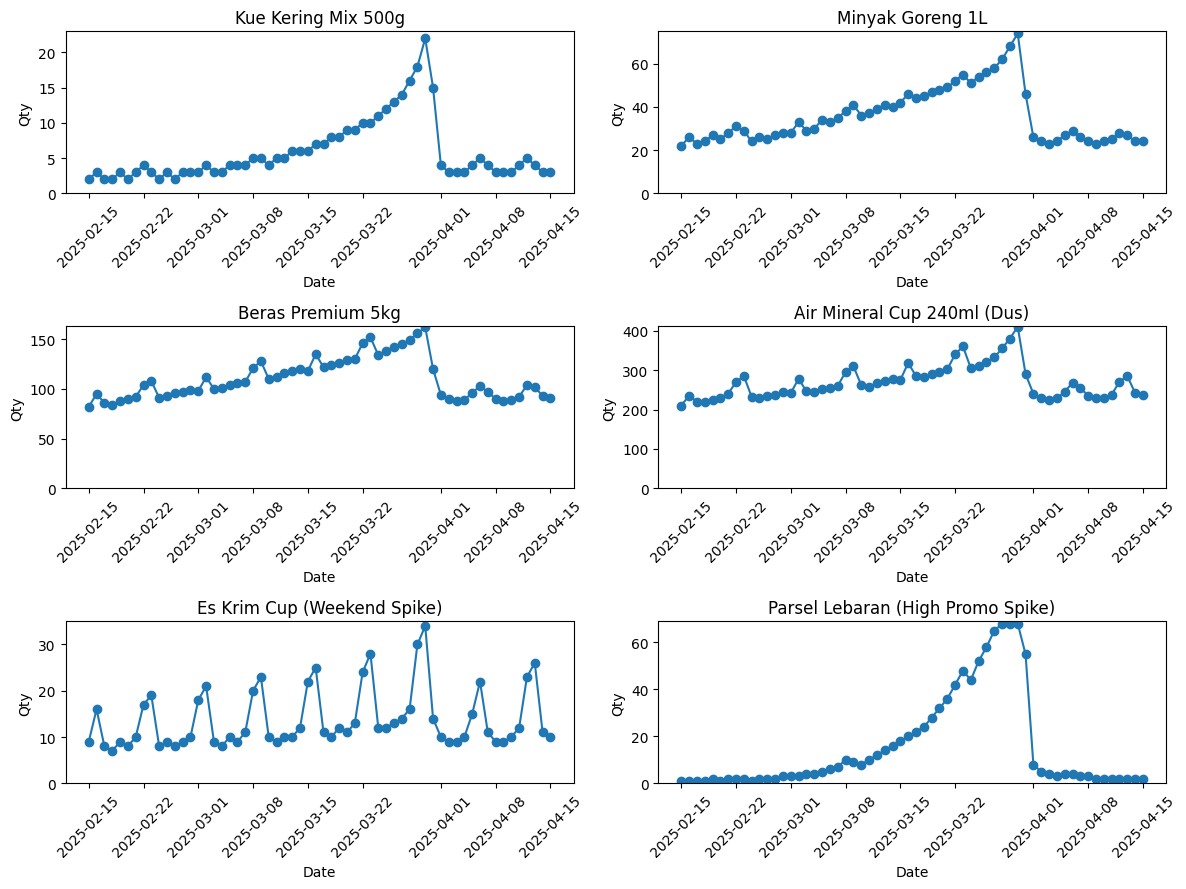

In [67]:
df_product["window_start"] = pd.to_datetime(df_product["window_start"])
df_product["window_end"] = pd.to_datetime(df_product["window_end"])

def plot_all_products(df, cols=2):
    n = len(df)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = axes.flatten()

    #looping sebanyak i sebagai index, value nya ada index sama row lagi
    for i, (_, r) in enumerate(df.iterrows()):
        sales = list(map(int, r["daily_sales"]))
        dates = pd.date_range(
            start=r["window_start"],
            periods=len(sales),
            freq="D"
        )

        ax = axes[i]
        ax.plot(dates, sales, marker="o")
        ax.set_title(r["product_name"])
        ax.set_xlabel("Date")
        ax.set_ylabel("Qty")
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylim(0, max(sales) + 1)

    # hapus axis kosong kalau jumlah produk < grid
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_all_products(df_product, cols=2)
plt.show()

In [68]:
rows = []

for _, r in df_product.iterrows():
    dates = pd.date_range(
        start=r["window_start"],
        periods=len(r["daily_sales"]),
        freq="D"
    )

    for d, qty in zip(dates, r["daily_sales"]):
        rows.append({
            "product_id": r["product_id"],
            "product_name": r["product_name"],
            "unit": r["unit"],
            "date": d,
            "qty": int(qty),
            "current_stock": r["current_stock"],
            "window_start": r["window_start"],
            "window_end": r["window_end"],
        })

df_ts = pd.DataFrame(rows)

In [69]:
df_ts["dow"] = df_ts["date"].dt.dayofweek
df_ts["is_weekend"] = df_ts["dow"].isin([5, 6]).astype(int)

In [70]:
df_ts["dow_sin"] = np.sin(2*np.pi*df_ts["dow"]/7)
df_ts["dow_cos"] = np.cos(2*np.pi*df_ts["dow"]/7)

In [71]:
id_holidays = holidays.Indonesia()

df_ts["is_holiday"] = df_ts["date"].dt.date.isin(id_holidays).astype(int)
df_ts["holiday_name"] = df_ts["date"].dt.date.map(lambda d: id_holidays.get(d)).fillna("")

In [72]:
EVENTS_2026 = {
    "lebaran_2026": ("2026-03-20", "2026-03-27"),
    "idul_adha_2026": ("2026-05-27", "2026-05-29"),
    "nataru_2026": ("2026-12-24", "2027-01-02"),
    "libur_sekolah_mid_2026": ("2026-06-15", "2026-07-15"),
    "libur_sekolah_end_2026": ("2026-12-15", "2027-01-05"),
    "tahun_baru_2026": ("2026-01-01", "2026-01-04"),
    "hari_buruh_2026": ("2026-05-01", "2026-05-03"),
    "kemerdekaan_2026": ("2026-08-17", "2026-08-18"),
}

In [73]:
for name, (start, end) in EVENTS_2026.items():
  start = pd.to_datetime(start)
  end = pd.to_datetime(end)
  mask = (df_ts['date'] >= start) & (df_ts['date'] <= end)

In [74]:
def add_lebaran_flags(df, lebaran_date):
    df = df.copy()
    d = pd.to_datetime(df["date"]).dt.normalize()

    lebaran_date = pd.to_datetime(lebaran_date).normalize()

    df["is_pre_lebaran_30d"] = (
        (d >= lebaran_date - pd.Timedelta(days=30)) &
        (d < lebaran_date)
    ).astype(int)

    df["is_lebaran"] = (d == lebaran_date).astype(int)

    df["is_post_lebaran_14d"] = (
        (d > lebaran_date) &
        (d <= lebaran_date + pd.Timedelta(days=14))
    ).astype(int)

    return df

In [75]:
df_ts = add_lebaran_flags(df_ts, data["lebaran_date"])

In [76]:
def compute_calendar_multipliers_from_g(train_g):
    eps = 1e-9
    tg = train_g.copy()

    base_mask = (
        (tg["is_weekend"] == 0) &
        (tg["is_pre_lebaran_30d"] == 0) &
        (tg["is_post_lebaran_14d"] == 0)
    )

    base = tg.loc[base_mask, "qty"].astype(float)
    base_mean = float(base.mean()) if len(base) > 0 else float(tg["qty"].astype(float).mean())
    base_mean = max(base_mean, eps)

    def ratio(mask, min_count=2):
        s = tg.loc[mask, "qty"].astype(float)
        if len(s) < min_count:
            return 1.0
        return float(s.mean() / base_mean)

    mult = {
        "weekend": ratio(tg["is_weekend"] == 1),
        "pre_lebaran": ratio(tg["is_pre_lebaran_30d"] == 1, min_count=1),
        "post_lebaran": ratio(tg["is_post_lebaran_14d"] == 1, min_count=1),
    }

    # clamp biar gak liar
    for k in mult:
        mult[k] = float(np.clip(mult[k], 0.5, 2.5))

    return mult


def apply_calendar_adjustment_to_test(base_forecast, test_g, mult):
    base_forecast = np.asarray(base_forecast, dtype=float)
    out = []
    for i in range(len(test_g)):
        m = 1.0
        row = test_g.iloc[i]
        if int(row["is_weekend"]) == 1: m *= mult["weekend"]
        if int(row["is_pre_lebaran_30d"]) == 1: m *= mult["pre_lebaran"]
        if int(row["is_post_lebaran_14d"]) == 1: m *= mult["post_lebaran"]
        out.append(base_forecast[i] * m)
    return np.asarray(out, dtype=float)

In [77]:
def build_future_flags(future_dates):
    df = pd.DataFrame({"date": pd.to_datetime(future_dates)})
    df["dow"] = df["date"].dt.dayofweek
    df["is_weekend"] = df["dow"].isin([5,6]).astype(int)

    df["is_pre_lebaran_30d"] = 0
    df["is_post_lebaran_14d"] = 0
    return df

def apply_calendar_adjustment(base_forecast, future_flags, mult):
    adj = []
    for i, yhat in enumerate(np.asarray(base_forecast, dtype=float)):
        m = 1.0
        if future_flags.loc[i, "is_weekend"] == 1:
            m *= mult["weekend"]
        if future_flags.loc[i, "is_pre_lebaran_30d"] == 1:
            m *= mult["pre_lebaran"]
        if future_flags.loc[i, "is_post_lebaran_14d"] == 1:
            m *= mult["post_lebaran"]

        adj.append(yhat * m)

    return np.asarray(adj, dtype=float)

In [78]:
exog_cols = [
    "is_weekend",
    "dow_sin",
    "dow_cos",
    "is_holiday",
    "is_pre_lebaran_30d",
    "is_lebaran",
    "is_post_lebaran_14d",
]

In [79]:
def prepare_sarimax_data(df, product_id):
  g = df_ts[df_ts["product_id"] == product_id].copy()
  g = g.sort_values("date")

  y = g["qty"].astype(float)

  # Use the globally defined exog_cols
  global exog_cols
  X = g[exog_cols].astype(float)
  scaler = StandardScaler()
  X_scaled = pd.DataFrame(
      scaler.fit_transform(X),
      columns=exog_cols,
      index=g.index
  )

  return y, X_scaled, scaler

In [80]:
def ewma_forecast(series, alpha=0.3, horizon=14):
    series = np.asarray(series, dtype=float)
    n = len(series)
    
    ewma_vals = np.zeros(n)
    ewma_vals[0] = series[0]
    
    for t in range(1, n):
        ewma_vals[t] = alpha * series[t] + (1 - alpha) * ewma_vals[t-1]
    
    last_ewma = ewma_vals[-1]
    forecast = np.full(horizon, last_ewma)
    
    return {
        'fitted': ewma_vals,
        'forecast': forecast,
        'last_value': last_ewma
    }


def ewma_pandas(series, alpha=0.3, horizon=14):
    s = pd.Series(series, dtype=float)
    ewma_vals = s.ewm(alpha=alpha, adjust=False).mean()
    last_ewma = ewma_vals.iloc[-1]
    forecast = np.full(horizon, last_ewma)
    
    return {
        'fitted': ewma_vals.to_numpy(),
        'forecast': forecast,
        'last_value': last_ewma
    }


def select_ewma_alpha(n_obs):
    if n_obs <= 21:
        return 0.3
    elif n_obs <= 40:
        return 0.25
    else:
        return 0.2

In [81]:
def train_sarimax_all_products(
    df_ts,
order=(1,1,1),
    seasonal_order=(1,0,1,7),
    product_col="product_id",
    date_col="date",
    min_obs=30,
    verbose=True
):
    df = df_ts.copy()
    df[product_col] = df[product_col].astype(str).str.strip()
    df[date_col] = pd.to_datetime(df[date_col])

    results = {}   
    rows = []    

    product_ids = df[product_col].dropna().unique().tolist()

    for pid in product_ids:
        g = df[df[product_col] == pid].sort_values(date_col)

        last_date = g[date_col].max()
        n_obs = len(g)

        pname = g["product_name"].iloc[0] if "product_name" in g.columns and n_obs > 0 else pid
        unit  = g["unit"].iloc[0] if "unit" in g.columns and n_obs > 0 else None

        if n_obs < min_obs:
            msg = f"skip: n_obs={n_obs} < min_obs={min_obs}"
            if verbose:
                print(f"[{pid}] {msg}")
            results[pid] = {
                "res": None,
                "scaler": None,
                "exog_cols": None,
                "last_date": last_date,
                "n_obs": n_obs,
                "error": msg
            }
            rows.append({
                "product_id": pid,
                "product_name": pname,
                "unit": unit,
                "n_obs": n_obs,
                "last_date": last_date,
                "aic": np.nan,
                "bic": np.nan,
                "hqic": np.nan,
                "llf": np.nan,
                "status": "SKIPPED",
                "error": msg
            })
            continue

        try:
            y, X, scaler = prepare_sarimax_data(df_ts, pid)

            # safety: pastikan X dan y align panjangnya
            if len(y) != len(X):
                raise ValueError(f"len(y)={len(y)} != len(X)={len(X)} (misaligned)")

            # safety: exog harus numeric semua
            X = X.apply(pd.to_numeric, errors="coerce")
            if X.isna().any().any():
                # ini penting: NaN di exog bikin estimasi kacau / singular
                X = X.fillna(0.0)

            model = SARIMAX(
                y,
                exog=X,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = model.fit(disp=False)

            results[pid] = {
                "res": res,
                "scaler": scaler,
                "exog_cols": list(X.columns),
                "last_date": last_date,
                "n_obs": len(y),
                "error": None
            }

            rows.append({
                "product_id": pid,
                "product_name": pname,
                "unit": unit,
                "n_obs": len(y),
                "last_date": last_date,
                "aic": float(res.aic),
                "bic": float(res.bic),
                "hqic": float(res.hqic),
                "llf": float(res.llf),
                "status": "OK",
                "error": ""
            })

            if verbose:
                print(f"[{pid}] OK | n={len(y)} | AIC={res.aic:.2f} | BIC={res.bic:.2f}")

        except Exception as e:
            msg = f"{type(e).__name__}: {e}"
            if verbose:
                print(f"[{pid}] FAIL | {msg}")

            results[pid] = {
                "res": None,
                "scaler": None,
                "exog_cols": None,
                "last_date": last_date,
                "n_obs": n_obs,
                "error": msg
            }
            rows.append({
                "product_id": pid,
                "product_name": pname,
                "unit": unit,
                "n_obs": n_obs,
                "last_date": last_date,
                "aic": np.nan,
                "bic": np.nan,
                "hqic": np.nan,
                "llf": np.nan,
                "status": "FAIL",
                "error": msg
            })

    scores_df = pd.DataFrame(rows).sort_values(["status", "aic"], ascending=[True, True])
    return scores_df, results

In [82]:
def prepare_sarimax_product_df(
    df_ts,
    product_id,
    product_col="product_id",
    date_col="date",
    qty_col="qty",
    exog_cols=("is_weekend", "is_holiday", "dow_sin", "dow_cos", "is_pre_lebaran_30d", "is_lebaran", "is_post_lebaran_14d")
):
    df = df_ts.copy()
    df[product_col] = df[product_col].astype(str).str.strip()
    df[date_col] = pd.to_datetime(df[date_col])

    g = df[df[product_col] == str(product_id)].sort_values(date_col).reset_index(drop=True)

    # target
    y = g[qty_col].astype(float).to_numpy()

    # exogenous
    X = g[list(exog_cols)].apply(pd.to_numeric, errors="coerce").fillna(0.0)

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        columns=X.columns,
        index=X.index
    )

    return y, X_scaled, scaler, list(X.columns), g

In [83]:
def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def wape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + eps))

In [84]:
def build_calendar_features(
    dates,
    holiday_dates=None,
    lebaran_date=None
):
    d = pd.to_datetime(pd.Series(dates)).dt.normalize()
    dow = d.dt.dayofweek

    is_weekend = (dow >= 5).astype(int)
    dow_sin = np.sin(2 * np.pi * dow / 7)
    dow_cos = np.cos(2 * np.pi * dow / 7)

    # Holiday features
    holiday_set = set(pd.to_datetime(list(holiday_dates)).normalize()) if holiday_dates is not None else set()
    is_holiday = d.isin(holiday_set).astype(int)

    # Lebaran features
    is_pre_lebaran_30d = np.zeros(len(d), dtype=int)
    is_lebaran = np.zeros(len(d), dtype=int)
    is_post_lebaran_14d = np.zeros(len(d), dtype=int)

    if lebaran_date:
        lebaran_dt = pd.to_datetime(lebaran_date).normalize()
        for i, dt in enumerate(d):
            if dt >= lebaran_dt - pd.Timedelta(days=30) and dt < lebaran_dt:
                is_pre_lebaran_30d[i] = 1
            elif dt == lebaran_dt:
                is_lebaran[i] = 1
            elif dt > lebaran_dt and dt <= lebaran_dt + pd.Timedelta(days=14):
                is_post_lebaran_14d[i] = 1

    return pd.DataFrame({
        "is_weekend": is_weekend,
        "dow_sin": dow_sin,
        "dow_cos": dow_cos,
        "is_holiday": is_holiday,
        "is_pre_lebaran_30d": is_pre_lebaran_30d,
        "is_lebaran": is_lebaran,
        "is_post_lebaran_14d": is_post_lebaran_14d,
    })


In [85]:
def build_future_calendar_features(
    start_date,
    horizon: int,
    holiday_dates=None,
    lebaran_date=None,
):

    start_date = pd.to_datetime(start_date)
    dates = pd.date_range(start=start_date, periods=horizon, freq="D")

    dow = dates.dayofweek
    is_weekend = (dow >= 5).astype(int)

    dow_sin = np.sin(2 * np.pi * dow / 7.0)
    dow_cos = np.cos(2 * np.pi * dow / 7.0)

    # Holiday features
    holiday_set = set(pd.to_datetime(list(holiday_dates)).normalize()) if holiday_dates is not None else set()
    is_holiday = pd.to_datetime(dates).normalize().isin(holiday_set).astype(int)

    # Lebaran features (assuming a single lebaran event for simplicity in future forecasting)
    is_pre_lebaran_30d = np.zeros(horizon, dtype=int)
    is_lebaran = np.zeros(horizon, dtype=int)
    is_post_lebaran_14d = np.zeros(horizon, dtype=int)

    if lebaran_date:
        lebaran_dt = pd.to_datetime(lebaran_date).normalize()
        for i, d in enumerate(dates.normalize()):
            if d >= lebaran_dt - pd.Timedelta(days=30) and d < lebaran_dt:
                is_pre_lebaran_30d[i] = 1
            elif d == lebaran_dt:
                is_lebaran[i] = 1
            elif d > lebaran_dt and d <= lebaran_dt + pd.Timedelta(days=14):
                is_post_lebaran_14d[i] = 1

    future_exog = pd.DataFrame({
        "is_weekend": is_weekend,
        "dow_sin": dow_sin,
        "dow_cos": dow_cos,
        "is_holiday": is_holiday,
        "is_pre_lebaran_30d": is_pre_lebaran_30d,
        "is_lebaran": is_lebaran,
        "is_post_lebaran_14d": is_post_lebaran_14d,
    })

    return future_exog

In [86]:
def rolling_backtest_sarimax_product(
    df_ts,
    product_id,
   order=(1,1,1),
    seasonal_order=(1,0,1,7),
    train_size=30,
    test_size=7,
    step=1,
    exog_cols=("is_weekend", "is_holiday", "dow_sin", "dow_cos", "is_pre_lebaran_30d", "is_lebaran", "is_post_lebaran_14d"),
    holiday_dates=None,
    event_dates=None,
    maxiter=50,
    method="lbfgs",
    max_folds=10,          # <-- ini yang lo butuh buat ngebatesin runtime
    product_col="product_id",
    date_col="date",
    qty_col="qty",
    scale_exog=False,
    lebaran_date=None
):
    """
    Return dict:
    - folds: list
    - wape_mean, mae_mean, rmse_mean
    - converged_ratio
    """
    pid = str(product_id).strip()
    df = df_ts.copy()
    df[product_col] = df[product_col].astype(str).str.strip()
    df[date_col] = pd.to_datetime(df[date_col])
    g = df[df[product_col] == pid].sort_values(date_col).reset_index(drop=True)

    n = len(g)
    folds = []
    wapes, maes, rmses = [], [], []
    converged_flags = []

    # guard: enough obs?
    if n < train_size + test_size:
        return {
            "folds": [],
            "wape_mean": None,
            "mae_mean": None,
            "rmse_mean": None,
            "converged_ratio": None,
            "error": f"n_obs={n} < train_size+test_size={train_size+test_size}"
        }

    fold_count = 0

    for start in range(0, n - (train_size + test_size) + 1, step):
        if max_folds is not None and fold_count >= int(max_folds):
            break

        train_g = g.iloc[start : start + train_size].copy()
        test_g  = g.iloc[start + train_size : start + train_size + test_size].copy()

        y_train = train_g[qty_col].astype(float).to_numpy()
        y_true  = test_g[qty_col].astype(float).to_numpy()

        # Build exog for train+test using same feature logic
        X_train_all = build_calendar_features(train_g[date_col], holiday_dates=holiday_dates, lebaran_date=lebaran_date)
        X_test_all  = build_calendar_features(test_g[date_col],  holiday_dates=holiday_dates, lebaran_date=lebaran_date)

        exog_cols = list(exog_cols)
        X_train = X_train_all[exog_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        X_test  = X_test_all[exog_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

        scaler = None
        if scale_exog:
            scaler = StandardScaler()
            X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=exog_cols)
            X_test  = pd.DataFrame(scaler.transform(X_test), columns=exog_cols)

        # Fit SARIMAX
        try:
            model = SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = model.fit(disp=False, maxiter=maxiter, method=method)
            converged = bool(getattr(res, "mle_retvals", {}).get("converged", True))
        except Exception as e:
            # mark fold fail, but keep pipeline running
            folds.append({
                "start_idx": start,
                "train_dates": train_g[date_col].astype(str).tolist(),
                "test_dates": test_g[date_col].astype(str).tolist(),
                "y_train": y_train.tolist(),
                "y_test": y_true.tolist(),
                "y_pred": None,
                "wape": None,
                "mae": None,
                "rmse": None,
                "error": f"{type(e).__name__}: {e}"
            })
            converged_flags.append(False)
            fold_count += 1
            continue

        # Forecast
        y_pred = res.forecast(steps=len(test_g), exog=X_test)
        y_pred = np.asarray(y_pred, dtype=float)

        fold_wape = wape(y_true, y_pred)
        fold_mae  = mae(y_true, y_pred)
        fold_rmse = rmse(y_true, y_pred)

        wapes.append(fold_wape)
        maes.append(fold_mae)
        rmses.append(fold_rmse)
        converged_flags.append(converged)

        folds.append({
            "start_idx": start,
            "train_dates": train_g[date_col].astype(str).tolist(),
            "test_dates": test_g[date_col].astype(str).tolist(),
            "y_train": y_train.tolist(),
            "y_test": y_true.tolist(),
            "y_pred": y_pred.tolist(),
            "wape": float(fold_wape),
            "mae": float(fold_mae),
            "rmse": float(fold_rmse),
            "converged": converged,
            "error": ""
        })

        fold_count += 1

    if len(wapes) == 0:
        return {
            "folds": folds,
            "wape_mean": None,
            "mae_mean": None,
            "rmse_mean": None,
            "converged_ratio": None,
            "error": "all folds failed or produced no predictions"
        }

    converged_ratio = float(np.mean([1.0 if x else 0.0 for x in converged_flags])) if converged_flags else None

    return {
        "folds": folds,
        "wape_mean": float(np.mean(wapes)),
        "mae_mean": float(np.mean(maes)),
        "rmse_mean": float(np.mean(rmses)),
        "converged_ratio": converged_ratio,
        "error": ""
    }

In [87]:
def backtest_sarimax_all_products(
    df_ts,
    order=(1,1,1),
    seasonal_order=(1,0,1,7),
    train_size=30,
    test_size=7,
    step=1,
    exog_cols=("is_weekend", "is_holiday", "dow_sin", "dow_cos","is_pre_lebaran_30d", "is_lebaran", "is_post_lebaran_14d"),

    holiday_dates=None,
    event_dates=None,
    maxiter=50,
    method="lbfgs",
    max_folds=10,        # <-- batas fold biar ga kelamaan
    min_obs=None,        # optional: skip product kalau obs kurang
    verbose=True,
    product_col="product_id",
    date_col="date",
    qty_col="qty",
    scale_exog=True
):
    rows = []
    details = {}

    df = df_ts.copy()
    df[product_col] = df[product_col].astype(str).str.strip()
    df[date_col] = pd.to_datetime(df[date_col])

    product_ids = df[product_col].dropna().unique().tolist()

    # default min_obs: minimal biar bisa rolling
    if min_obs is None:
        min_obs = train_size + test_size

    for pid in product_ids:
        g = df[df[product_col] == pid].sort_values(date_col)
        n_obs = len(g)
        pname = g["product_name"].iloc[0] if ("product_name" in g.columns and n_obs > 0) else pid
        unit  = g["unit"].iloc[0] if ("unit" in g.columns and n_obs > 0) else None

        if n_obs < min_obs:
            msg = f"SKIP n_obs={n_obs} < min_obs={min_obs}"
            if verbose:
                print(f"[{pid}] {msg}")
            details[pid] = {"folds": [], "wape_mean": None, "mae_mean": None, "rmse_mean": None, "converged_ratio": None, "error": msg}
            rows.append({
                "product_id": pid, "product_name": pname, "unit": unit,
                "wape": np.nan, "mae": np.nan, "rmse": np.nan,
                "n_folds": 0, "converged_ratio": np.nan,
                "status": "SKIPPED", "error": msg
            })
            continue

        try:
            res = rolling_backtest_sarimax_product(
                df_ts=df,
                product_id=pid,
                order=order,
                seasonal_order=seasonal_order,
                train_size=train_size,
                test_size=test_size,
                step=step,
                exog_cols=exog_cols,
                holiday_dates=holiday_dates,
                event_dates=event_dates,
                maxiter=maxiter,
                method=method,
                max_folds=max_folds,
                product_col=product_col,
                date_col=date_col,
                qty_col=qty_col,
                scale_exog=scale_exog
            )

            details[pid] = res

            status = "OK" if res.get("wape_mean") is not None else "FAIL"
            err = res.get("error", "")

            rows.append({
                "product_id": pid,
                "product_name": pname,
                "unit": unit,
                "wape": res.get("wape_mean", np.nan),
                "mae": res.get("mae_mean", np.nan),
                "rmse": res.get("rmse_mean", np.nan),
                "n_folds": len(res.get("folds", [])),
                "converged_ratio": res.get("converged_ratio", np.nan),
                "status": status,
                "error": err
            })

            if verbose and status == "OK":
                print(f"[{pid}] OK | folds={len(res['folds'])} | WAPE={res['wape_mean']*100:.1f}% | conv={res['converged_ratio']:.2f}")
            elif verbose:
                print(f"[{pid}] FAIL | {err}")

        except Exception as e:
            msg = f"{type(e).__name__}: {e}"
            if verbose:
                print(f"[{pid}] FAIL | {msg}")

            details[pid] = {"folds": [], "wape_mean": None, "mae_mean": None, "rmse_mean": None, "converged_ratio": None, "error": msg}
            rows.append({
                "product_id": pid, "product_name": pname, "unit": unit,
                "wape": np.nan, "mae": np.nan, "rmse": np.nan,
                "n_folds": 0, "converged_ratio": np.nan,
                "status": "FAIL", "error": msg
            })

    scores_df = pd.DataFrame(rows)
    scores_df = scores_df.sort_values(["status", "wape"], na_position="last").reset_index(drop=True)
    return scores_df, details

In [88]:
df_ts


,product_id,product_name,unit,date,qty,current_stock,window_start,window_end,dow,is_weekend,dow_sin,dow_cos,is_holiday,holiday_name,is_pre_lebaran_30d,is_lebaran,is_post_lebaran_14d
0,PROD_001,Kue Kering Mix 500g,PACK,2025-02-15,2,22,2025-02-15,2025-04-15,5,1,-0.974928,-0.222521,0,,0,0,0
1,PROD_001,Kue Kering Mix 500g,PACK,2025-02-16,3,22,2025-02-15,2025-04-15,6,1,-0.781831,0.623490,0,,0,0,0
2,PROD_001,Kue Kering Mix 500g,PACK,2025-02-17,2,22,2025-02-15,2025-04-15,0,0,0.000000,1.000000,0,,0,0,0
3,PROD_001,Kue Kering Mix 500g,PACK,2025-02-18,2,22,2025-02-15,2025-04-15,1,0,0.781831,0.623490,0,,0,0,0
4,PROD_001,Kue Kering Mix 500g,PACK,2025-02-19,3,22,2025-02-15,2025-04-15,2,0,0.974928,-0.222521,0,,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,PROD_006,Parsel Lebaran (High Promo Spike),BOX,2025-04-11,2,9,2025-02-15,2025-04-15,4,0,-0.433884,-0.900969,0,,0,0,1
356,PROD_006,Parsel Lebaran (High Promo Spike),BOX,2025-04-12,2,9,2025-02-15,2025-04-15,5,1,-0.974928,-0.222521,0,,0,0,1
357,PROD_006,Parsel Lebaran (High Promo Spike),BOX,2025-04-13,2,9,2025-02-15,2025-04-15,6,1,-0.781831,0.623490,0,,0,0,1
358,PROD_006,Parsel Lebaran (High Promo Spike),BOX,2025-04-14,2,9,2025-02-15,2025-04-15,0,0,0.000000,1.000000,0,,0,0,1


In [89]:
backtest_sarimax_all_products(df_ts)

/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximu

[PROD_001] OK | folds=10 | WAPE=19.7% | conv=0.50


/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximu

[PROD_002] OK | folds=10 | WAPE=9.8% | conv=0.60


/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximu

[PROD_005] OK | folds=10 | WAPE=6.3% | conv=0.00


/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[PROD_006] OK | folds=10 | WAPE=16.3% | conv=0.60


(  product_id                       product_name    unit      wape        mae  \
 0   PROD_003                  Beras Premium 5kg  KARUNG  0.059383   8.268473   
 1   PROD_005        Es Krim Cup (Weekend Spike)     CUP  0.062514   1.100396   
 2   PROD_004        Air Mineral Cup 240ml (Dus)     DUS  0.069270  22.716624   
 3   PROD_002                   Minyak Goreng 1L     PCS  0.097980   5.340048   
 4   PROD_006  Parsel Lebaran (High Promo Spike)     BOX  0.162625   8.751493   
 5   PROD_001                Kue Kering Mix 500g    PACK  0.197425   2.430921   
 
         rmse  n_folds  converged_ratio status error  
 0   9.991983       10              0.5     OK        
 1   1.369351       10              0.0     OK        
 2  26.813043       10              0.3     OK        
 3   6.438690       10              0.6     OK        
 4  11.745148       10              0.6     OK        
 5   3.028475       10              0.5     OK        ,
 {'PROD_001': {'folds': [{'start_idx': 0,
   

In [90]:
def plot_sarimax_forecast_all_products(
    df_ts,
    results,
    scores_df,
    horizon=14,
    product_col="product_id",
    holiday_dates=None,
    lebaran_date=None
):
    product_ids = list(results.keys())

    for pid in product_ids:
        r = results[pid]
        if r["res"] is None:
            print(f"[SKIP] {pid} -> {r['error']}")
            continue

        try:
            print(f"[PLOT] {pid}")
            plot_sarimax_forecast(
            df_ts=df_ts,
            results=results,
            product_id=pid,
            horizon=14,
            scores_df=scores_df,
            show_acc_box=True,
            show_acc_table=True,
            holiday_dates=holiday_dates,
            lebaran_date=lebaran_date
        )
        except Exception as e:
            print(f"[ERROR] {pid}: {type(e).__name__} - {e}")

In [91]:
last_date = pd.to_datetime(df_ts["date"]).max()

In [92]:
future_exog = build_future_calendar_features(
    start_date=last_date + pd.Timedelta(days=1),
    horizon=14,
)[exog_cols]

In [93]:
def plot_sarimax_forecast(
    df_ts,
    results,
    product_id,
    horizon=14,
    date_col="date",
    qty_col="qty",
    product_col="product_id",
    scores_df=None,
    show_last_n=60,
    show_acc_in_legend=False,
    show_acc_box=True,
    show_acc_table=True,
    holiday_dates=None,
    lebaran_date=None
):
    pid = str(product_id).strip()
    if pid not in results:
        raise ValueError(f"{pid} not found in trained results")

    r = results[pid]
    if r["res"] is None:
        raise ValueError(f"SARIMAX not trained for {pid}: {r['error']}")

    g = df_ts.copy()
    g[product_col] = g[product_col].astype(str).str.strip()
    g[date_col] = pd.to_datetime(g[date_col])
    g = g[g[product_col] == pid].sort_values(date_col)
    if g.empty:
        raise ValueError(f"No data found in df_ts for product {pid}")

    # only show last N days on chart
    g_plot = g.iloc[-show_last_n:] if (show_last_n and len(g) > show_last_n) else g

    dates_hist = g_plot[date_col]
    y_hist = g_plot[qty_col].astype(float).to_numpy()

    last_date = pd.to_datetime(r["last_date"])
    exog_cols = list(r["exog_cols"])

    # Assuming lebaran_date for forecasting is available in 'data'
    lebaran_date_for_forecast = data["lebaran_date"]

    future_exog = build_future_calendar_features(
        start_date=last_date + pd.Timedelta(days=1),
        horizon=horizon,
        holiday_dates=holiday_dates, # Pass holiday dates
        lebaran_date=lebaran_date # Pass lebaran date
    )[exog_cols]

    if r.get("scaler") is not None:
        future_exog_scaled = pd.DataFrame(
            r["scaler"].transform(future_exog),
            columns=exog_cols
        )
    else:
        future_exog_scaled = future_exog

    forecast = r["res"].forecast(steps=horizon, exog=future_exog_scaled)
    forecast = np.asarray(forecast, dtype=float)

    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=horizon,
        freq="D"
    )

    # -------- metrics lookup (always on if available) --------
    wape = mae_ = rmse_ = np.nan
    metrics_text = "WAPE=N/A | MAE=N/A | RMSE=N/A"

    if isinstance(scores_df, pd.DataFrame) and ("product_id" in scores_df.columns):
        tmp = scores_df.copy()
        tmp["product_id"] = tmp["product_id"].astype(str).str.strip()
        row = tmp[tmp["product_id"] == pid]
        if not row.empty:
            row = row.iloc[0]
            wape = row.get("wape", np.nan)
            mae_ = row.get("mae", np.nan)
            rmse_ = row.get("rmse", np.nan)

            # WAPE biasanya fraction (0.xx)
            if pd.notna(wape):
                metrics_text = f"WAPE={wape*100:.1f}% | MAE={mae_:.2f} | RMSE={rmse_:.2f}"
            else:
                metrics_text = f"MAE={mae_:.2f} | RMSE={rmse_:.2f}"

    # -------- plotting --------
    # kalau show_acc_table aktif, beri ruang bawah
    fig_h = 6.5 if show_acc_table else 5
    fig, ax = plt.subplots(figsize=(12, fig_h))

    ax.plot(dates_hist, y_hist, marker="o", label="Actual (Historical)", linewidth=2)
    ax.axvline(last_date, linestyle="--", color="gray", label="Forecast Boundary")

    forecast_label = "SARIMAX Forecast"
    if show_acc_in_legend and metrics_text:
        forecast_label = f"SARIMAX Forecast ({metrics_text})"

    ax.plot(future_dates, forecast, marker="o", linestyle="--", label=forecast_label, linewidth=2)

    pname = g["product_name"].iloc[0] if "product_name" in g.columns else pid
    ax.set_title(f"SARIMAX Forecast – {pname} ({pid})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Qty")
    ax.grid(alpha=0.3)
    ax.legend()

    # metrics box (lebih presentable daripada legend)
    if show_acc_box and metrics_text:
        ax.text(
            0.01, 0.98,
            metrics_text,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="gray", alpha=0.9),
        )

    plt.tight_layout()
    plt.show()

In [94]:
def plot_sarimax_forecast_all_products(
    df_ts,
    results,
    scores_df,
    horizon=14,
    product_col="product_id",
    holiday_dates=None,
    lebaran_date=None
):
    product_ids = list(results.keys())

    for pid in product_ids:
        r = results[pid]
        if r["res"] is None:
            print(f"[SKIP] {pid} -> {r['error']}")
            continue

        try:
            print(f"[PLOT] {pid}")
            plot_sarimax_forecast(
            df_ts=df_ts,
            results=results,
            product_id=pid,
            horizon=14,
            scores_df=scores_df,
            show_acc_box=True,
            show_acc_table=True,
            holiday_dates=holiday_dates,
            lebaran_date=lebaran_date
        )
        except Exception as e:
            print(f"[ERROR] {pid}: {type(e).__name__} - {e}")

[PROD_001] OK | n=60 | AIC=204.64 | BIC=227.58
[PROD_002] OK | n=60 | AIC=288.20 | BIC=311.14


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting

[PROD_003] OK | n=60 | AIC=343.12 | BIC=366.07


/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimiz

[PROD_004] OK | n=60 | AIC=430.71 | BIC=453.65
[PROD_005] OK | n=60 | AIC=222.50 | BIC=245.45


/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimiz

[PROD_006] OK | n=60 | AIC=311.88 | BIC=334.83
[PLOT] PROD_001


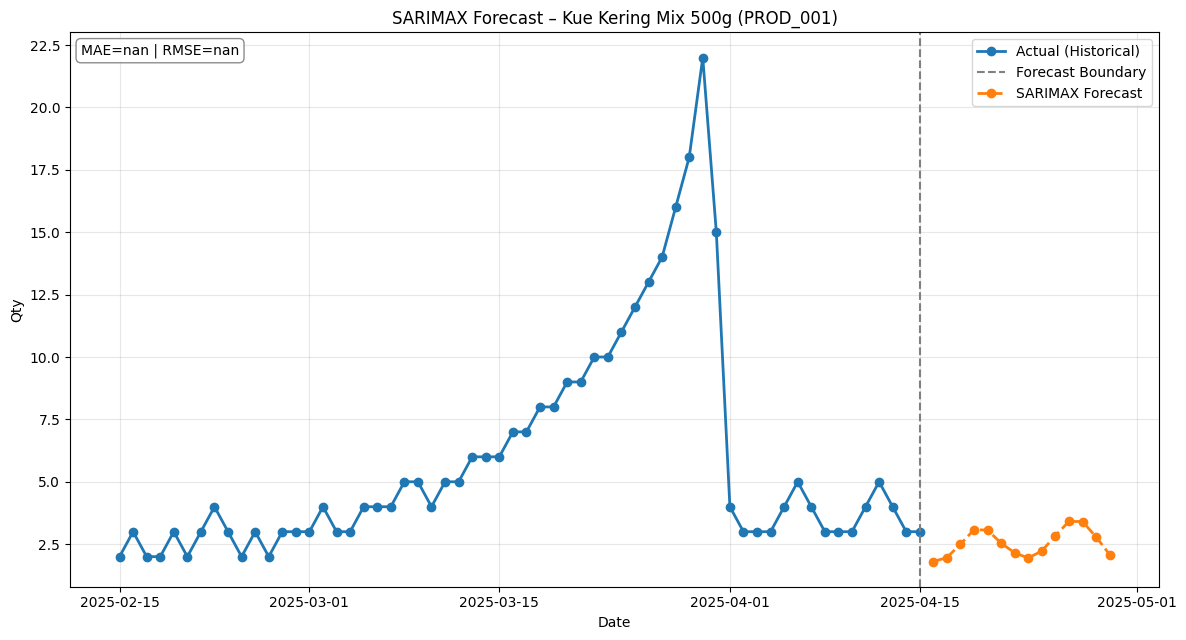

[PLOT] PROD_002


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


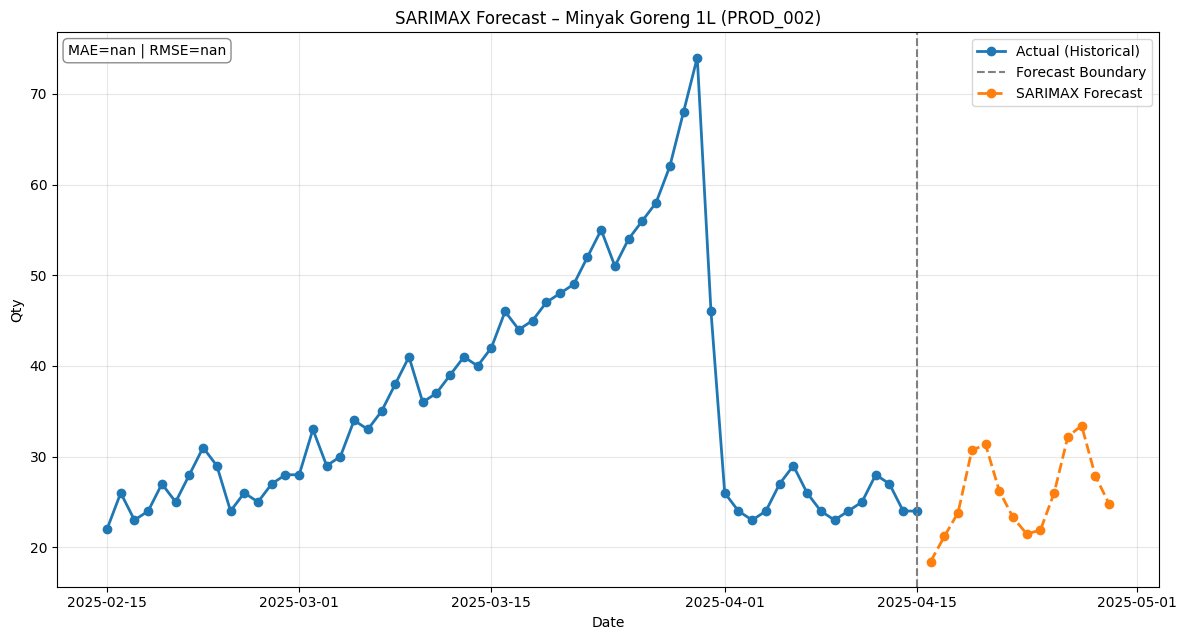

[PLOT] PROD_003


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


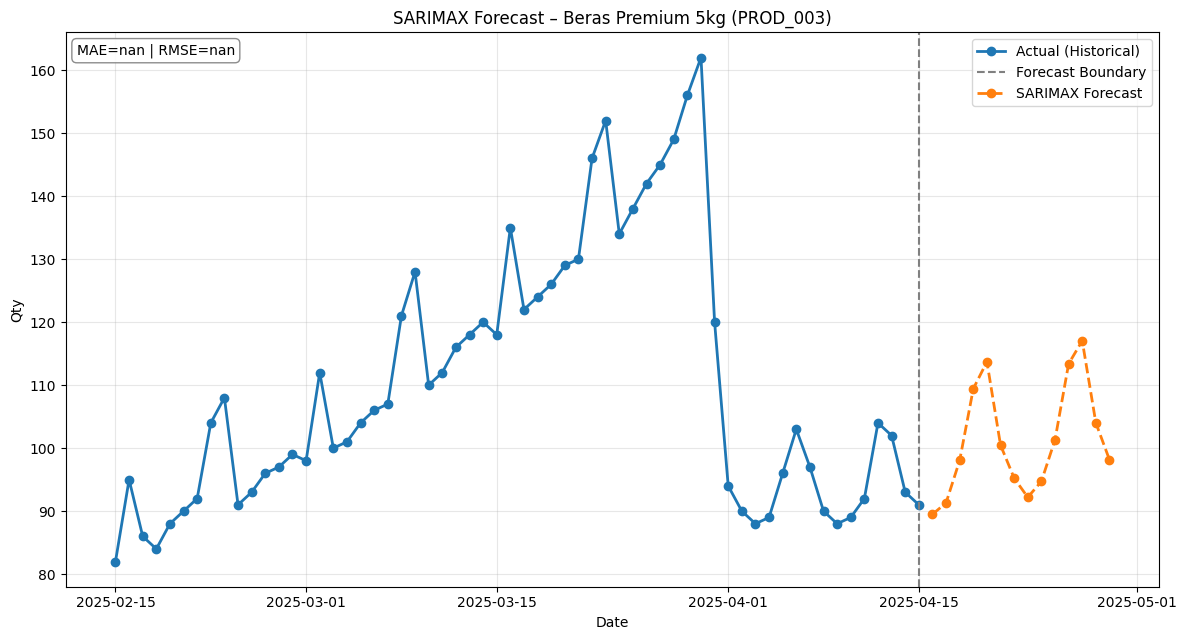

[PLOT] PROD_004


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


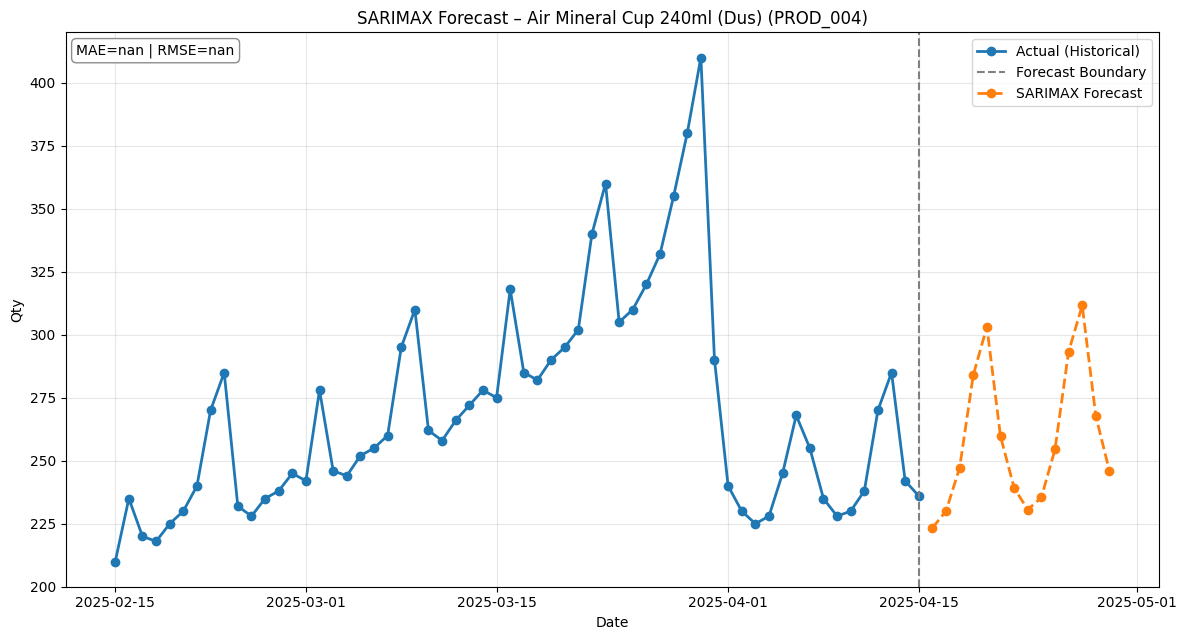

[PLOT] PROD_005


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


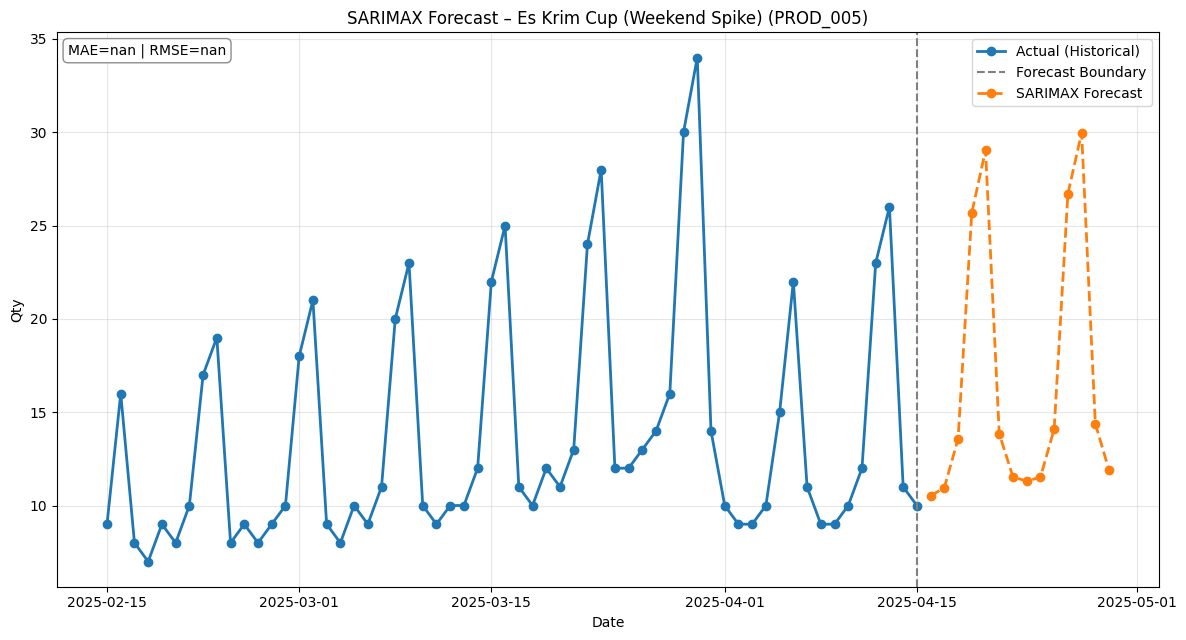

[PLOT] PROD_006


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


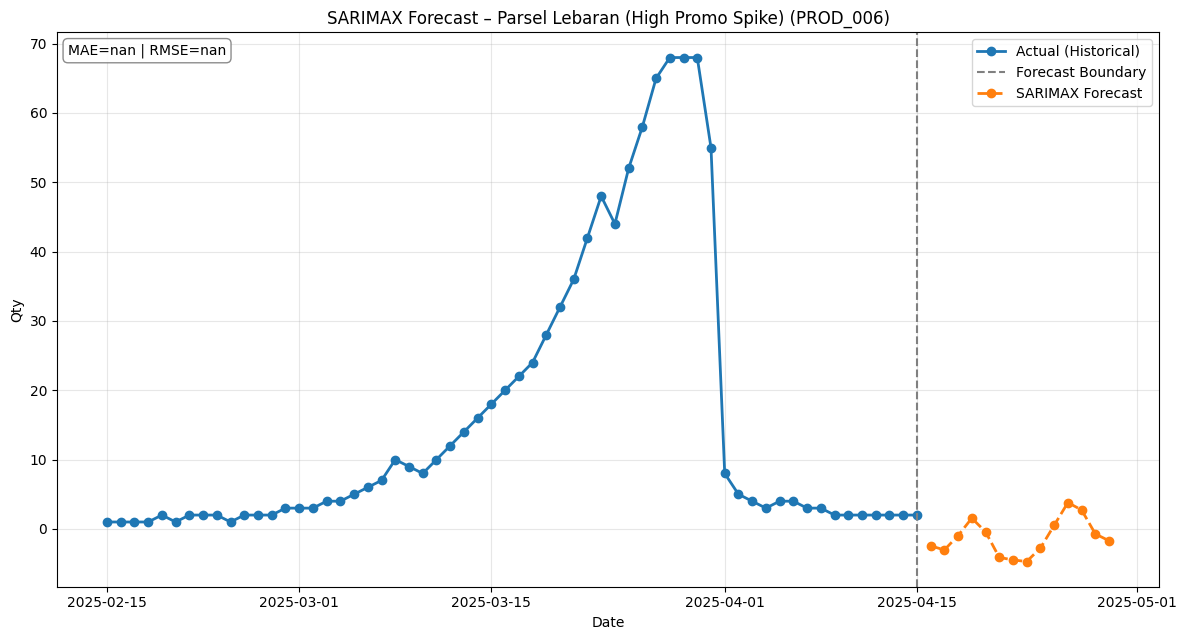

In [95]:
scores_df, results = train_sarimax_all_products(df_ts)

plot_sarimax_forecast_all_products(
    scores_df=scores_df,
    df_ts=df_ts,
    results=results,
    horizon=14,
    holiday_dates=id_holidays.keys(),
    lebaran_date=data["lebaran_date"]
)

In [96]:
def should_use_ewma_fallback(sarimax_wape, sarimax_forecast, ewma_forecast, threshold=0.5):
    if pd.notna(sarimax_wape) and sarimax_wape > threshold:
        return 'ewma'
    
    sarimax_mean = np.mean(sarimax_forecast)
    ewma_mean = np.mean(ewma_forecast)
    
    if sarimax_mean > 3 * ewma_mean and ewma_mean > 1:
        return 'blend'
    
    if np.any(sarimax_forecast < 0):
        return 'ewma'
    
    return 'sarimax'


def blend_forecasts(sarimax_fc, ewma_fc, weight=0.7):
    sarimax_fc = np.asarray(sarimax_fc, dtype=float)
    ewma_fc = np.asarray(ewma_fc, dtype=float)
    
    return weight * sarimax_fc + (1 - weight) * ewma_fc

In [97]:
def select_ewma_alpha(n_obs, recent_trend=None):
    if n_obs <= 21:
        base_alpha = 0.3
    elif n_obs <= 40:
        base_alpha = 0.25
    else:
        base_alpha = 0.2
    
    if recent_trend is not None:
        if abs(recent_trend) > 0.2:  
            base_alpha = min(base_alpha + 0.1, 0.4)  
    
    return base_alpha


def ewma_with_trend(series, alpha=0.3, horizon=14):
    """
    EWMA with trend adjustment for better forecasting.
    """
    series = np.asarray(series, dtype=float)
    n = len(series)
    
    if n < 3:
        return ewma_pandas(series, alpha=alpha, horizon=horizon)
    
    s = pd.Series(series)
    ewma_vals = s.ewm(alpha=alpha, adjust=False).mean()
    last_ewma = ewma_vals.iloc[-1]
    
    lookback = min(7, n)
    recent_vals = series[-lookback:]
    
    # Simple linear trend
    x = np.arange(lookback)
    slope, intercept = np.polyfit(x, recent_vals, 1)
    
    # Project with trend
    forecast = []
    for h in range(1, horizon + 1):
        # Dampen trend over time (avoid infinite growth)
        damping = 0.9 ** h  # Exponential decay
        projected = last_ewma + (slope * h * damping)
        
        # Safety bounds: don't go negative or too wild
        projected = max(projected, 0)
        projected = min(projected, last_ewma * 3)  # Max 3x last value
        
        forecast.append(projected)
    
    return {
        'fitted': ewma_vals.to_numpy(),
        'forecast': np.array(forecast),
        'last_value': last_ewma,
        'trend_slope': slope
    }


def hybrid_forecast(
    df_ts,
    results,
    scores_df,
    product_id,
    horizon=14,
    use_ewma_fallback=True,
    blend_threshold=0.5
):
    """
    Enhanced hybrid forecast with trend-aware EWMA.
    """
    pid = str(product_id).strip()
    
    g = df_ts[df_ts["product_id"] == pid].copy()
    g = g.sort_values("date")
    y_hist = g["qty"].astype(float).to_numpy()
    
    # Check data quality
    n_obs = len(y_hist)
    
    # === CRITICAL FIX: Handle very short data ===
    if n_obs < 7:
        # Use simple average for very short series
        avg_sales = np.mean(y_hist)
        simple_fc = np.full(horizon, avg_sales)
        return {
            'forecast': simple_fc,
            'method': 'simple_average',
            'confidence': 'low',
            'reason': f'Only {n_obs} days of data - using simple average'
        }
    
    # === Trend-aware EWMA ===
    alpha = select_ewma_alpha(n_obs)
    ewma_result = ewma_with_trend(y_hist, alpha=alpha, horizon=horizon)
    ewma_fc = ewma_result['forecast']
    trend_slope = ewma_result.get('trend_slope', 0)
    
    # === SARIMAX forecast ===
    r = results.get(pid)
    if r is None or r["res"] is None:
        return {
            'forecast': ewma_fc,
            'method': 'ewma_with_trend',
            'confidence': 'medium' if n_obs >= 14 else 'low',
            'reason': 'SARIMAX not available'
        }
    
    last_date = pd.to_datetime(r["last_date"])
    exog_cols = list(r["exog_cols"])
    
    future_exog = build_future_calendar_features(
        start_date=last_date + pd.Timedelta(days=1),
        horizon=horizon,
        holiday_dates=id_holidays.keys(),
        lebaran_date=data["lebaran_date"]
    )[exog_cols]
    
    if r.get("scaler") is not None:
        future_exog_scaled = pd.DataFrame(
            r["scaler"].transform(future_exog),
            columns=exog_cols
        )
    else:
        future_exog_scaled = future_exog
    
    sarimax_fc = r["res"].forecast(steps=horizon, exog=future_exog_scaled)
    sarimax_fc = np.asarray(sarimax_fc, dtype=float)
    
    # === Get backtest WAPE ===
    wape_val = np.nan
    if isinstance(scores_df, pd.DataFrame):
        tmp = scores_df[scores_df["product_id"].astype(str).str.strip() == pid]
        if not tmp.empty:
            wape_val = tmp.iloc[0].get("wape", np.nan)
    
    if not use_ewma_fallback:
        return {
            'forecast': sarimax_fc,
            'method': 'sarimax_only',
            'confidence': 'medium'
        }
    
    # === Enhanced decision logic ===
    decision = should_use_ewma_fallback(wape_val, sarimax_fc, ewma_fc, threshold=blend_threshold)
    
    # Additional check: if EWMA trend is strong and SARIMAX is flat → trust EWMA
    sarimax_std = np.std(sarimax_fc)
    if abs(trend_slope) > 0.5 and sarimax_std < 1.0:
        decision = 'ewma'
    
    if decision == 'ewma':
        return {
            'forecast': ewma_fc,
            'method': 'ewma_override',
            'confidence': 'medium',
            'reason': f'SARIMAX WAPE={wape_val*100:.1f}% or trend detected'
        }
    elif decision == 'blend':
        # Adjust blend weight based on trend strength
        if abs(trend_slope) > 0.3:
            weight = 0.4  # More EWMA weight if trending
        else:
            weight = 0.6  # Default SARIMAX weight
        
        blended = blend_forecasts(sarimax_fc, ewma_fc, weight=weight)
        return {
            'forecast': blended,
            'method': 'hybrid_blend',
            'confidence': 'high',
            'reason': f'Blended: {int(weight*100)}% SARIMAX, {int((1-weight)*100)}% EWMA'
        }
    else:
        return {
            'forecast': sarimax_fc,
            'method': 'sarimax_trusted',
            'confidence': 'high'
        }

# ...existing code...

In [98]:
scores_df, results = train_sarimax_all_products(df_ts)

for pid in results.keys():
    forecast_result = hybrid_forecast(
        df_ts=df_ts,
        results=results,
        scores_df=scores_df,
        product_id=pid,
        horizon=14,
        use_ewma_fallback=True
    )
    
    print(f"[{pid}] Method: {forecast_result['method']} | Confidence: {forecast_result['confidence']}")
    print(f"  Forecast (next 3 days): {forecast_result['forecast'][:3]}")
    if 'reason' in forecast_result:
        print(f"  Reason: {forecast_result['reason']}")

[PROD_001] OK | n=60 | AIC=204.64 | BIC=227.58
[PROD_002] OK | n=60 | AIC=288.20 | BIC=311.14


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting

[PROD_003] OK | n=60 | AIC=343.12 | BIC=366.07
[PROD_004] OK | n=60 | AIC=430.71 | BIC=453.65
[PROD_005] OK | n=60 | AIC=222.50 | BIC=245.45
[PROD_006] OK | n=60 | AIC=311.88 | BIC=334.83
[PROD_001] Method: sarimax_trusted | Confidence: high
  Forecast (next 3 days): [1.80464033 1.9620174  2.49881748]
[PROD_002] Method: sarimax_trusted | Confidence: high
  Forecast (next 3 days): [18.43484541 21.19618784 23.83010183]
[PROD_003] Method: sarimax_trusted | Confidence: high
  Forecast (next 3 days): [89.4863747  91.3194299  98.05702731]
[PROD_004] Method: sarimax_trusted | Confidence: high
  Forecast (next 3 days): [223.30369077 230.05229663 247.23809475]
[PROD_005] Method: sarimax_trusted | Confidence: high
  Forecast (next 3 days): [10.50875996 10.96425985 13.56844517]
[PROD_006] Method: ewma_override | Confidence: medium
  Forecast (next 3 days): [4.22473293 4.22473293 4.22473293]
  Reason: SARIMAX WAPE=nan% or trend detected


/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimiz

In [99]:
def plot_hybrid_forecast(
    df_ts,
    results,
    scores_df,
    product_id,
    horizon=14,
    date_col="date",
    qty_col="qty",
    product_col="product_id",
    show_last_n=60,
    use_ewma_fallback=True,
    blend_threshold=0.5,
    holiday_dates=None,
    lebaran_date=None
):
    pid = str(product_id).strip()
    
    g = df_ts.copy()
    g[product_col] = g[product_col].astype(str).str.strip()
    g[date_col] = pd.to_datetime(g[date_col])
    g = g[g[product_col] == pid].sort_values(date_col)
    
    if g.empty:
        print(f"[SKIP] {pid}: No data found")
        return
    
    g_plot = g.iloc[-show_last_n:] if (show_last_n and len(g) > show_last_n) else g
    dates_hist = g_plot[date_col]
    y_hist = g_plot[qty_col].astype(float).to_numpy()
    
    y_all = g[qty_col].astype(float).to_numpy()
    last_date = g[date_col].max()
    
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=horizon,
        freq="D"
    )
    
    alpha = select_ewma_alpha(len(y_all))
    ewma_result = ewma_pandas(y_all, alpha=alpha, horizon=horizon)
    ewma_fc = ewma_result['forecast']
    
    r = results.get(pid)
    sarimax_fc = None
    sarimax_available = False
    
    if r is not None and r["res"] is not None:
        try:
            exog_cols = list(r["exog_cols"])
            future_exog = build_future_calendar_features(
                start_date=last_date + pd.Timedelta(days=1),
                horizon=horizon,
                holiday_dates=holiday_dates,
                lebaran_date=lebaran_date
            )[exog_cols]
            
            if r.get("scaler") is not None:
                future_exog_scaled = pd.DataFrame(
                    r["scaler"].transform(future_exog),
                    columns=exog_cols
                )
            else:
                future_exog_scaled = future_exog
            
            sarimax_fc = r["res"].forecast(steps=horizon, exog=future_exog_scaled)
            sarimax_fc = np.asarray(sarimax_fc, dtype=float)
            sarimax_available = True
        except Exception as e:
            print(f"[WARNING] {pid}: SARIMAX forecast failed - {e}")
    
    hybrid_result = hybrid_forecast(
        df_ts=df_ts,
        results=results,
        scores_df=scores_df,
        product_id=pid,
        horizon=horizon,
        use_ewma_fallback=use_ewma_fallback,
        blend_threshold=blend_threshold
    )
    
    final_fc = hybrid_result['forecast']
    method = hybrid_result['method']
    confidence = hybrid_result['confidence']
    reason = hybrid_result.get('reason', '')
    
    wape_val = mae_val = rmse_val = np.nan
    if isinstance(scores_df, pd.DataFrame) and "product_id" in scores_df.columns:
        tmp = scores_df[scores_df["product_id"].astype(str).str.strip() == pid]
        if not tmp.empty:
            wape_val = tmp.iloc[0].get("wape", np.nan)
            mae_val = tmp.iloc[0].get("mae", np.nan)
            rmse_val = tmp.iloc[0].get("rmse", np.nan)
    
    # === Plotting ===
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Historical
    ax.plot(dates_hist, y_hist, marker="o", color="steelblue", 
            label="Actual (Historical)", linewidth=2, markersize=4)
    
    # Forecast boundary
    ax.axvline(last_date, linestyle="--", color="gray", alpha=0.5, 
               label="Forecast Start", linewidth=1.5)
    
    # SARIMAX forecast (if available)
    if sarimax_available and sarimax_fc is not None:
        ax.plot(future_dates, sarimax_fc, marker="^", linestyle="--", 
                color="tomato", label="SARIMAX Forecast", 
                linewidth=1.5, markersize=5, alpha=0.7)
    
    # EWMA baseline
    ax.plot(future_dates, ewma_fc, marker="s", linestyle="--", 
            color="mediumseagreen", label=f"EWMA Baseline (α={alpha:.2f})", 
            linewidth=1.5, markersize=5, alpha=0.7)
    
    # Final hybrid forecast
    method_colors = {
        'sarimax_trusted': 'tomato',
        'ewma_override': 'mediumseagreen',
        'hybrid_blend': 'mediumpurple',
        'ewma_only': 'mediumseagreen',
        'sarimax_only': 'tomato'
    }
    final_color = method_colors.get(method, 'mediumpurple')
    
    ax.plot(future_dates, final_fc, marker="o", linestyle="-", 
            color=final_color, label=f"Final Forecast ({method.replace('_', ' ').title()})", 
            linewidth=3, markersize=6, alpha=0.9, zorder=5)
    
    # Title and labels
    pname = g["product_name"].iloc[0] if "product_name" in g.columns else pid
    ax.set_title(f"Hybrid Forecast – {pname} ({pid})", fontsize=14, fontweight='bold')
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Quantity", fontsize=11)
    ax.grid(alpha=0.3, linestyle=':', linewidth=0.8)
    ax.legend(loc='best', fontsize=9)
    
    # === Info boxes ===
    # Metrics box (top-left)
    if pd.notna(wape_val):
        metrics_text = f"Backtest Metrics\nWAPE: {wape_val*100:.1f}%\nMAE: {mae_val:.2f}\nRMSE: {rmse_val:.2f}"
    else:
        metrics_text = "Backtest Metrics\nN/A"
    
    ax.text(
        0.01, 0.98,
        metrics_text,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", 
                  edgecolor="steelblue", alpha=0.9, linewidth=1.5),
        family='monospace'
    )
    
    # Decision box (top-right)
    confidence_emoji = {'high': '✓', 'medium': '~', 'low': '⚠'}
    emoji = confidence_emoji.get(confidence, '?')
    
    decision_text = f"Decision: {method.replace('_', ' ').title()}\n"
    decision_text += f"Confidence: {confidence.upper()} {emoji}\n"
    if reason:
        # Wrap long text
        reason_wrapped = reason[:50] + '...' if len(reason) > 50 else reason
        decision_text += f"Reason: {reason_wrapped}"
    
    ax.text(
        0.99, 0.98,
        decision_text,
        transform=ax.transAxes,
        va="top", ha="right",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", 
                  edgecolor="orange", alpha=0.9, linewidth=1.5),
        family='monospace'
    )
    
    # Forecast summary (bottom-right)
    forecast_summary = f"Next 3 days: {final_fc[0]:.1f}, {final_fc[1]:.1f}, {final_fc[2]:.1f}\n"
    forecast_summary += f"14-day avg: {np.mean(final_fc):.1f}"
    
    ax.text(
        0.99, 0.02,
        forecast_summary,
        transform=ax.transAxes,
        va="bottom", ha="right",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightcyan", 
                  edgecolor="teal", alpha=0.9, linewidth=1.5),
        family='monospace'
    )
    
    plt.tight_layout()
    plt.show()


def plot_hybrid_forecast_all_products(
    df_ts,
    results,
    scores_df,
    horizon=14,
    product_col="product_id",
    use_ewma_fallback=True,
    blend_threshold=0.5,
    holiday_dates=None,
    lebaran_date=None
):
    """
    Plot hybrid forecasts for all products.
    """
    product_ids = df_ts[product_col].dropna().unique().tolist()
    
    for pid in product_ids:
        try:
            print(f"\n[PLOT] {pid}")
            plot_hybrid_forecast(
                df_ts=df_ts,
                results=results,
                scores_df=scores_df,
                product_id=pid,
                horizon=horizon,
                use_ewma_fallback=use_ewma_fallback,
                blend_threshold=blend_threshold,
                holiday_dates=holiday_dates,
                lebaran_date=lebaran_date
            )
        except Exception as e:
            print(f"[ERROR] {pid}: {type(e).__name__} - {e}")

[PROD_001] OK | n=60 | AIC=204.64 | BIC=227.58
[PROD_002] OK | n=60 | AIC=288.20 | BIC=311.14


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting

[PROD_003] OK | n=60 | AIC=343.12 | BIC=366.07
[PROD_004] OK | n=60 | AIC=430.71 | BIC=453.65


/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimiz

[PROD_005] OK | n=60 | AIC=222.50 | BIC=245.45
[PROD_006] OK | n=60 | AIC=311.88 | BIC=334.83

[PLOT] PROD_001


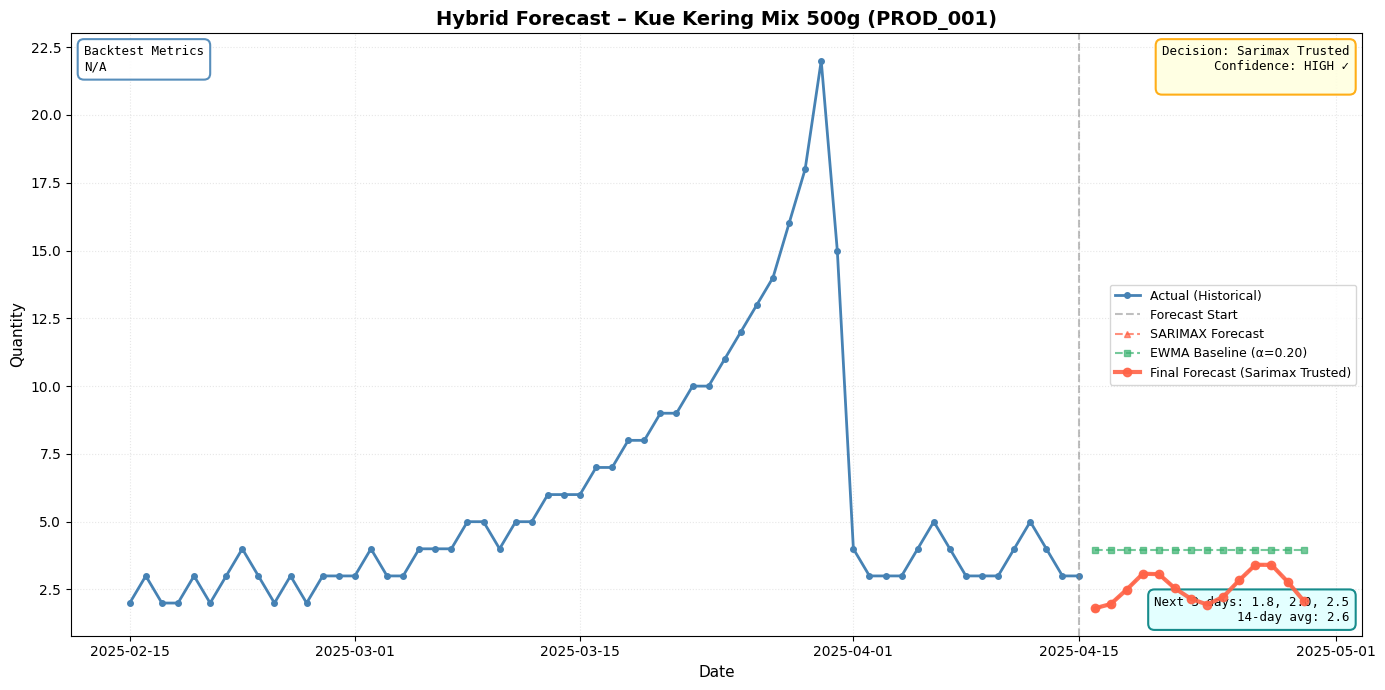


[PLOT] PROD_002


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predicti

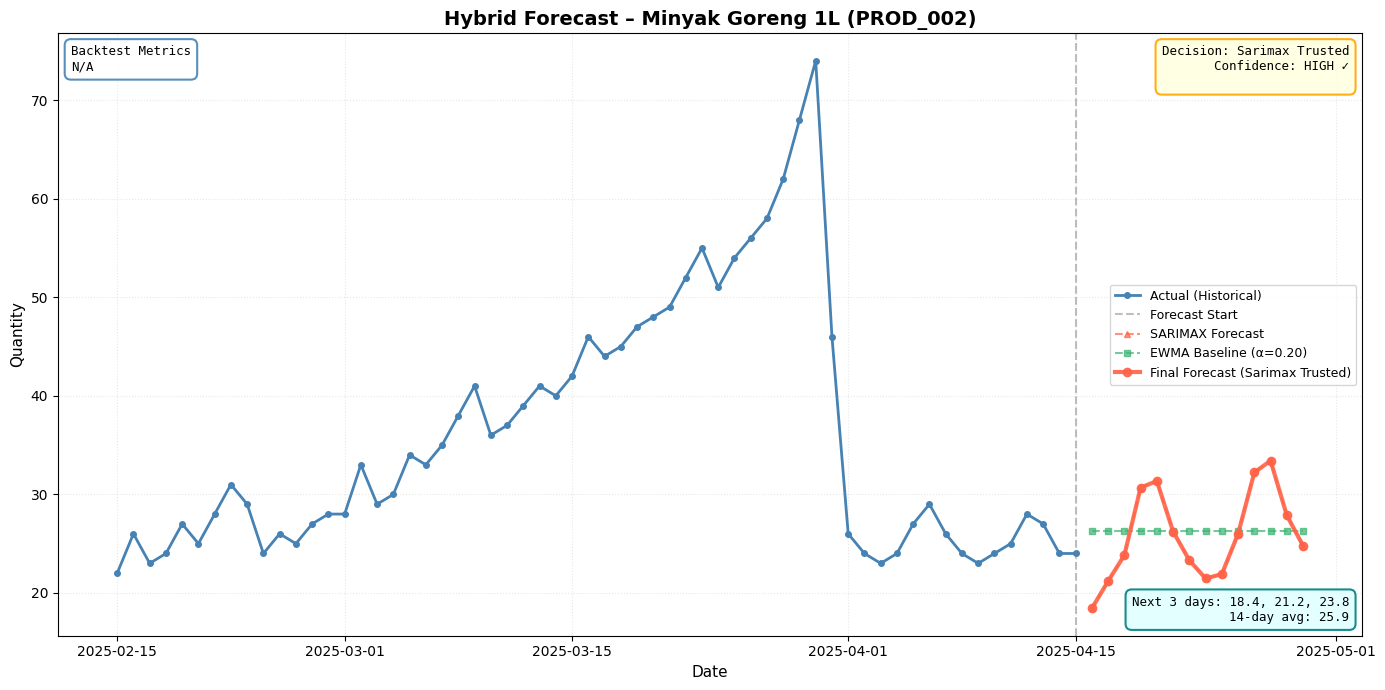


[PLOT] PROD_003


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predicti

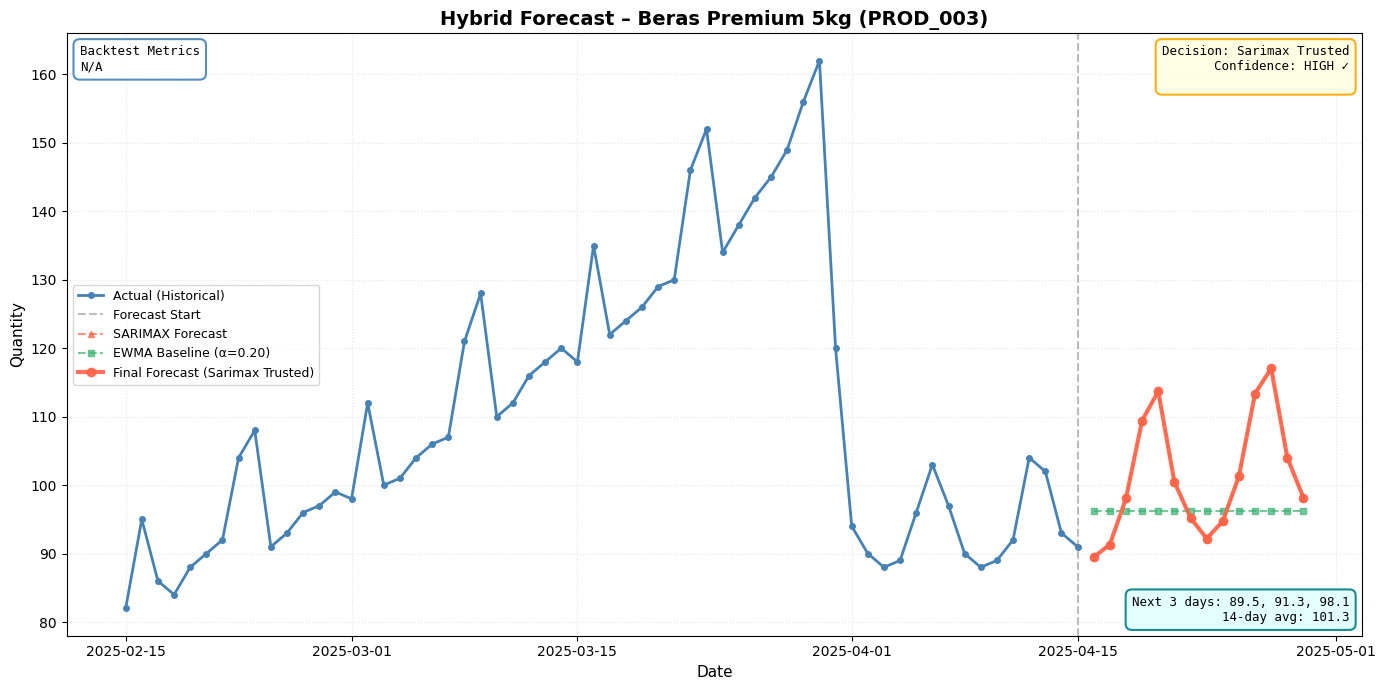


[PLOT] PROD_004


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predicti

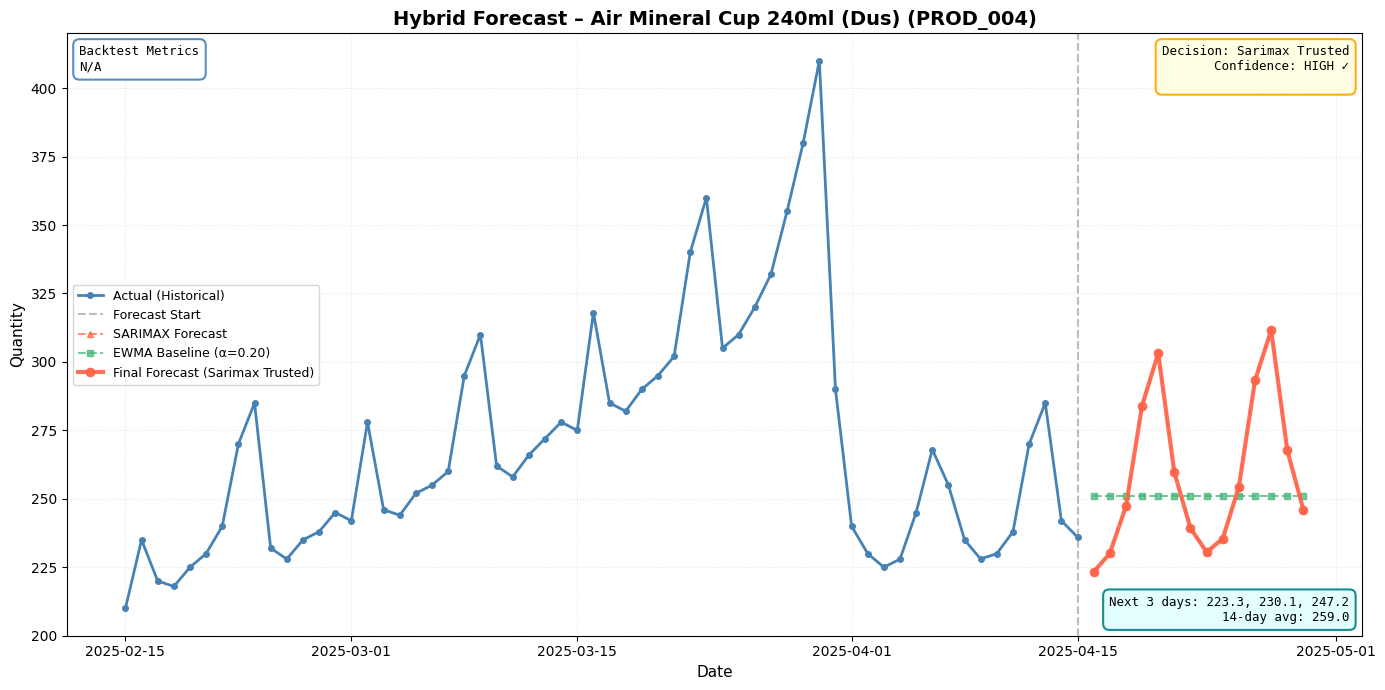


[PLOT] PROD_005


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predicti

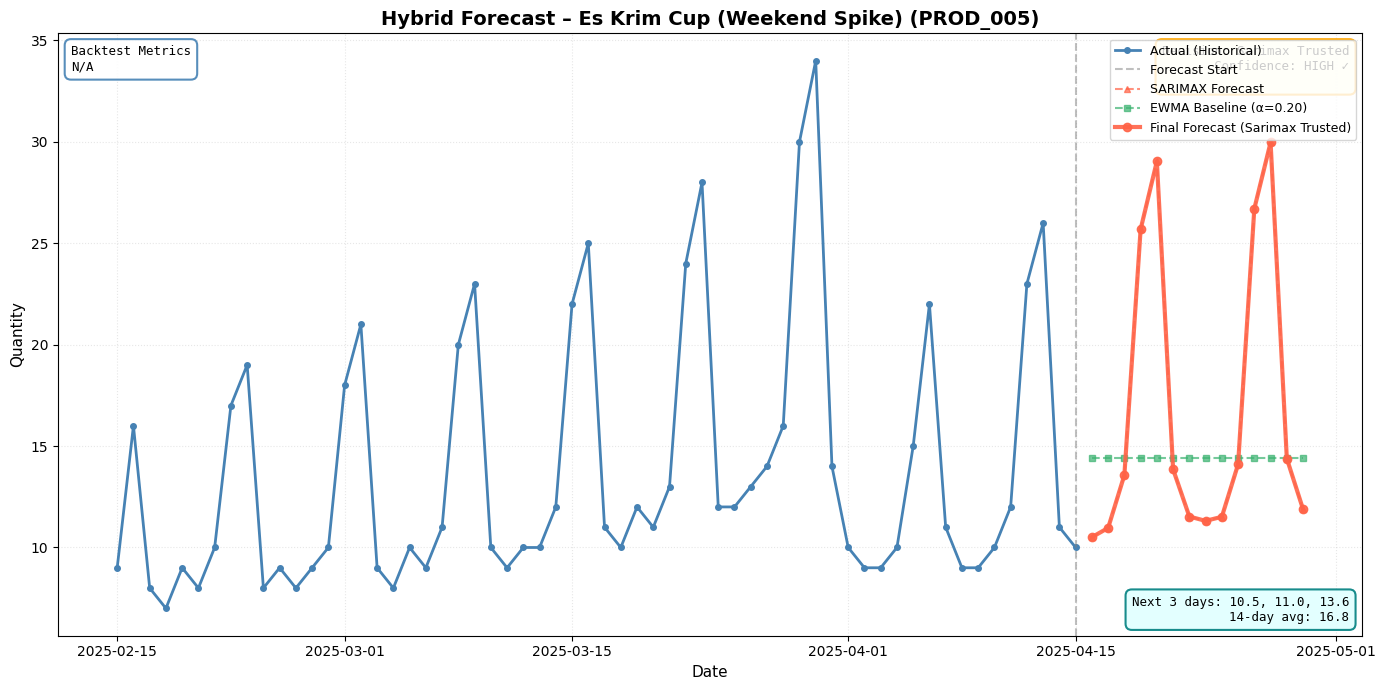


[PLOT] PROD_006


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predicti

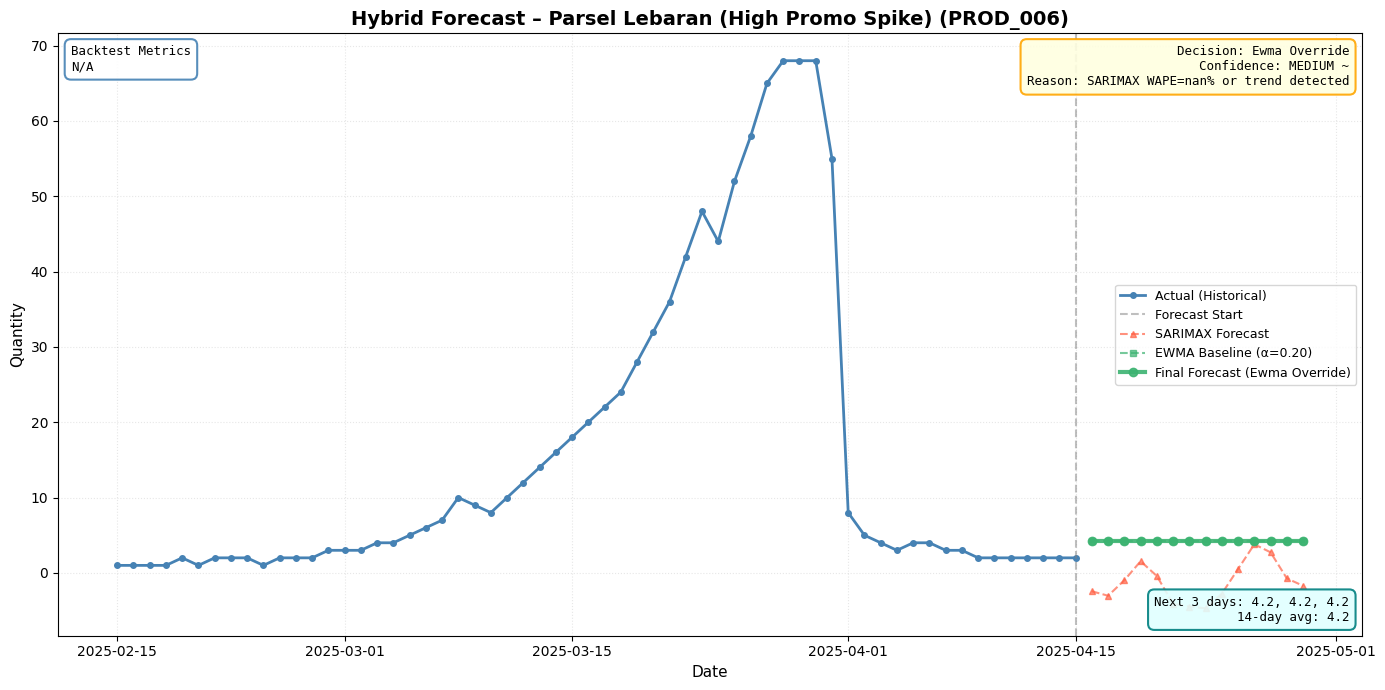

In [100]:
scores_df, results = train_sarimax_all_products(df_ts)

plot_hybrid_forecast_all_products(
    df_ts=df_ts,
    results=results,
    scores_df=scores_df,
    horizon=14,
    use_ewma_fallback=True,
    blend_threshold=0.5,
    holiday_dates=id_holidays.keys(),
    lebaran_date=data["lebaran_date"]
)

In [101]:
scores_df, results = train_sarimax_all_products(df_ts)

for pid in df_ts['product_id'].unique():
    print(f"\n{'='*50}")
    print(f"Testing {pid}")
    print(f"{'='*50}")
    
    forecast_result = hybrid_forecast(
        df_ts=df_ts,
        results=results,
        scores_df=scores_df,
        product_id=pid,
        horizon=14,
        use_ewma_fallback=True
    )
    
    print(f"Method: {forecast_result['method']}")
    print(f"Confidence: {forecast_result['confidence']}")
    print(f"Reason: {forecast_result.get('reason', 'N/A')}")
    print(f"Forecast (14 days): {forecast_result['forecast'][:14]}")
    print(f"14-day avg: {np.mean(forecast_result['forecast']):.2f}")

[PROD_001] OK | n=60 | AIC=204.64 | BIC=227.58
[PROD_002] OK | n=60 | AIC=288.20 | BIC=311.14


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting

[PROD_003] OK | n=60 | AIC=343.12 | BIC=366.07
[PROD_004] OK | n=60 | AIC=430.71 | BIC=453.65
[PROD_005] OK | n=60 | AIC=222.50 | BIC=245.45
[PROD_006] OK | n=60 | AIC=311.88 | BIC=334.83

Testing PROD_001
Method: sarimax_trusted
Confidence: high
Reason: N/A
Forecast (14 days): [1.80464033 1.9620174  2.49881748 3.08067557 3.06483222 2.5395963
 2.15200849 1.9454692  2.22838472 2.84402338 3.41138897 3.40714238
 2.78812407 2.08348356]
14-day avg: 2.56

Testing PROD_002
Method: sarimax_trusted
Confidence: high
Reason: N/A
Forecast (14 days): [18.43484541 21.19618784 23.83010183 30.68813273 31.35389891 26.23055465
 23.30826982 21.46799787 21.90664539 25.99583239 32.21813618 33.41397154
 27.86943771 24.7867267 ]
14-day avg: 25.91

Testing PROD_003
Method: sarimax_trusted
Confidence: high
Reason: N/A
Forecast (14 days): [ 89.4863747   91.3194299   98.05702731 109.43426991 113.70738265
 100.4727417   95.23182971  92.19704227  94.72123734 101.3105842
 113.38416491 117.03993896 104.00451811  98.

/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimiz

In [102]:
llm_payload = []
for pid in df_ts['product_id'].unique():
    forecast_result = hybrid_forecast(
        df_ts=df_ts,
        results=results,
        scores_df=scores_df,
        product_id=pid,
        horizon=14,
        use_ewma_fallback=True
    )

    forecast_14 = [math.ceil(x) for x in forecast_result['forecast'][:14]]
    total_14 = sum(forecast_14)
    avg_14 = round(np.mean(forecast_14), 2)

    product_obj = {
        "product_id": pid,
        "method": forecast_result["method"],
        "confidence": forecast_result["confidence"],
        "reason": forecast_result.get("reason"),
        "forecast": {
            "horizon_days": 14,
            "daily": forecast_14,
            "total": total_14,
            "average_per_day": avg_14
        }
    }

    llm_payload.append(product_obj)

/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predicti

In [103]:
llm_input_json = json.dumps(
    {
        "generated_at": "2026-01-08",
        "model": "hybrid_sarimax_ewma",
        "products": llm_payload
    },
    indent=2
)

print(llm_input_json)

{
  "generated_at": "2026-01-08",
  "model": "hybrid_sarimax_ewma",
  "products": [
    {
      "product_id": "PROD_001",
      "method": "sarimax_trusted",
      "confidence": "high",
      "reason": null,
      "forecast": {
        "horizon_days": 14,
        "daily": [
          2,
          2,
          3,
          4,
          4,
          3,
          3,
          2,
          3,
          3,
          4,
          4,
          3,
          3
        ],
        "total": 43,
        "average_per_day": 3.07
      }
    },
    {
      "product_id": "PROD_002",
      "method": "sarimax_trusted",
      "confidence": "high",
      "reason": null,
      "forecast": {
        "horizon_days": 14,
        "daily": [
          19,
          22,
          24,
          31,
          32,
          27,
          24,
          22,
          22,
          26,
          33,
          34,
          28,
          25
        ],
        "total": 369,
        "average_per_day": 26.36
      }
    },


In [ ]:
def estimate_days_until_stockout(current_stock, daily_forecast):
    """Hitung berapa hari lagi stok habis."""
    cumulative = 0
    for day, qty in enumerate(daily_forecast, start=1):
        cumulative += qty
        if cumulative >= current_stock:
            return day
    return None


def calculate_risk_and_urgency(days_until_stockout, forecast_mean, wape, current_stock):
    """Calculate risk level and urgency score."""
    if days_until_stockout is None:
        risk_level = "LOW"
        urgency_score = 10
    elif days_until_stockout <= 3:
        risk_level = "HIGH"
        urgency_score = 70
    elif days_until_stockout <= 7:
        risk_level = "MEDIUM"
        urgency_score = 50
    else:
        risk_level = "LOW"
        urgency_score = 30
    
    return {
        "risk_level": risk_level,
        "urgency_score": urgency_score
    }


def decide_restock_action(current_stock, forecast_total_14, forecast_mean, risk_level, days_until_stockout, safety_stock_multiplier=1.5):
    """Decide restock action with quantity range."""
    safety_stock = int(forecast_mean * 7 * safety_stock_multiplier)
    
    if risk_level == "HIGH":
        qty_min = int((forecast_total_14 + safety_stock) - current_stock)
        qty_max = int(qty_min * 1.5)
        return {
            "action": "RESTOCK",
            "qty_min": max(qty_min, 0),
            "qty_max": qty_max,
            "reason": f"HIGH RISK: Stock runs out in {days_until_stockout} days. Predicted demand exceeds current stock."
        }
    
    elif risk_level == "MEDIUM":
        qty_min = int((forecast_total_14 * 0.7 + safety_stock) - current_stock)
        qty_max = int(qty_min * 1.5)
        return {
            "action": "RESTOCK",
            "qty_min": max(qty_min, 0),
            "qty_max": qty_max,
            "reason": f"MEDIUM RISK: Stock runs out in {days_until_stockout} days. Moderate restock needed."
        }
    
    else:
        if current_stock < safety_stock:
            qty_min = int(safety_stock - current_stock)
            qty_max = int(qty_min * 1.2)
            return {
                "action": "RESTOCK",
                "qty_min": qty_min,
                "qty_max": qty_max,
                "reason": "LOW RISK: Stock sufficient for now, but restock recommended."
            }
        else:
            return {
                "action": "WAIT",
                "qty_min": 0,
                "qty_max": 0,
                "reason": "Stock sufficient for forecast period. Monitor and wait."
            }


# === BARU: Analisis Pattern untuk Business Insights ===
def analyze_sales_patterns(df_ts, product_id):
    """Analisis pola penjualan untuk business insights."""
    g = df_ts[df_ts["product_id"] == product_id].copy()
    g = g.sort_values("date")
    
    if len(g) < 7:
        return {
            "trend": "insufficient_data",
            "volatility": "unknown",
            "weekend_effect": None,
            "growth_rate": None,
            "seasonality": "unknown"
        }
    
    sales = g["qty"].astype(float).to_numpy()
    
    # 1. Trend Analysis
    x = np.arange(len(sales))
    slope, _ = np.polyfit(x, sales, 1)
    
    if slope > 0.5:
        trend = "growing"
    elif slope < -0.5:
        trend = "declining"
    else:
        trend = "stable"
    
    # 2. Volatility (Coefficient of Variation)
    cv = np.std(sales) / (np.mean(sales) + 1e-9)
    if cv > 0.5:
        volatility = "high"
    elif cv > 0.3:
        volatility = "medium"
    else:
        volatility = "low"
    
    # 3. Weekend Effect
    weekend_avg = g[g["is_weekend"] == 1]["qty"].mean()
    weekday_avg = g[g["is_weekend"] == 0]["qty"].mean()
    
    if pd.notna(weekend_avg) and pd.notna(weekday_avg) and weekday_avg > 0:
        weekend_ratio = weekend_avg / weekday_avg
        if weekend_ratio > 1.3:
            weekend_effect = "strong_increase"
        elif weekend_ratio < 0.7:
            weekend_effect = "strong_decrease"
        else:
            weekend_effect = "neutral"
    else:
        weekend_effect = None
    
    # 4. Growth Rate (last 7 days vs previous 7 days)
    if len(sales) >= 14:
        recent_avg = np.mean(sales[-7:])
        previous_avg = np.mean(sales[-14:-7])
        growth_rate = ((recent_avg - previous_avg) / (previous_avg + 1e-9)) * 100
    else:
        growth_rate = None
    
    # 5. Seasonality Check (simplified)
    if len(sales) >= 21:
        weekly_pattern = sales.reshape(-1, 7) if len(sales) % 7 == 0 else None
        if weekly_pattern is not None:
            weekly_std = np.std(np.mean(weekly_pattern, axis=0))
            seasonality = "detected" if weekly_std > np.mean(sales) * 0.2 else "weak"
        else:
            seasonality = "unknown"
    else:
        seasonality = "unknown"
    
    return {
        "trend": trend,
        "volatility": volatility,
        "weekend_effect": weekend_effect,
        "growth_rate": growth_rate,
        "seasonality": seasonality,
        "avg_daily_sales": float(np.mean(sales)),
        "coefficient_of_variation": float(cv)
    }


def calculate_business_priority(product_data, sales_patterns):
    """Calculate business priority score (0-100) untuk prioritas restock."""
    score = 0
    
    # 1. Urgency Score (40 points)
    urgency = product_data['stock_analysis']['urgency_score']
    score += (urgency / 100) * 40
    
    # 2. Demand Volume (20 points)
    avg_demand = product_data['forecast']['average_per_day']
    if avg_demand > 100:
        score += 20
    elif avg_demand > 50:
        score += 15
    elif avg_demand > 20:
        score += 10
    elif avg_demand > 5:
        score += 5
    
    # 3. Volatility Impact (15 points)
    if sales_patterns['volatility'] == "high":
        score += 15  # High volatility = higher risk
    elif sales_patterns['volatility'] == "medium":
        score += 10
    else:
        score += 5
    
    # 4. Growth Trend (15 points)
    if sales_patterns['trend'] == "growing":
        score += 15
    elif sales_patterns['trend'] == "stable":
        score += 10
    elif sales_patterns['trend'] == "declining":
        score += 5
    
    # 5. Forecast Reliability (10 points)
    reliability = product_data['stock_analysis']['forecast_reliability']
    if reliability == "HIGH":
        score += 10
    elif reliability == "MEDIUM":
        score += 6
    else:
        score += 3
    
    return int(min(score, 100))


def generate_batch_llm_analysis(products_data, model="gpt-4o-mini", batch_size=3):
    """
    Generate LLM analysis untuk multiple products sekaligus (batch).
    Lebih efisien dan hemat API calls.
    """
    import time
    
    results = []
    total_tokens = 0
    
    sorted_products = sorted(
        products_data, 
        key=lambda x: (
            x['stock_analysis']['risk_level'] == 'HIGH',
            x['business_priority']['priority_score']
        ),
        reverse=True
    )
    
    for i in range(0, len(sorted_products), batch_size):
        batch = sorted_products[i:i+batch_size]
        
        batch_prompts = []
        for idx, p in enumerate(batch, start=1):
            prompt = f"""
**PRODUK {idx}: {p['product_name']}**
- Stok: {p['current_stock']} {p['unit']}
- Permintaan 14 hari: {p['forecast']['total_demand']} {p['unit']} (rata-rata {p['forecast']['average_per_day']}/hari)
- Risiko: {p['stock_analysis']['risk_level']} (habis dalam {p['stock_analysis']['days_until_stockout'] or '>14'} hari)
- Rekomendasi: {p['recommendation']['action']} ({p['recommendation']['quantity_range']['min']}-{p['recommendation']['quantity_range']['max']} {p['unit']})
- Pattern: Trend {p['business_insights']['sales_patterns']['trend']}, Volatilitas {p['business_insights']['sales_patterns']['volatility']}
- Priority Score: {p['business_priority']['priority_score']}/100 (Tier: {p['business_priority']['priority_tier']})
"""
            batch_prompts.append(prompt)
        
        combined_prompt = f"""
Anda adalah ahli manajemen inventori untuk bisnis retail. Analisis {len(batch)} produk berikut dan berikan insight singkat untuk MASING-MASING produk dalam bahasa Indonesia.

{chr(10).join(batch_prompts)}

Untuk SETIAP produk, berikan analisis dalam format:

**[NAMA PRODUK]**
**Kesimpulan:** (1 kalimat - kondisi kritis atau aman?)
**Tindakan:** (1 kalimat - apa yang harus dilakukan sekarang?)
**Impact:** (1 kalimat - konsekuensi jika tidak bertindak?)

Gunakan bahasa praktis dan fokus pada keputusan bisnis. Prioritaskan produk risiko tinggi.
"""
        
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": "Anda adalah expert inventory manager yang memberikan rekomendasi praktis untuk pemilik usaha retail."},
                    {"role": "user", "content": combined_prompt}
                ],
                temperature=0.7,
                max_tokens=800
            )
            
            llm_output = response.choices[0].message.content
            total_tokens += response.usage.total_tokens
            
            lines = llm_output.split('\n')
            current_product = None
            current_text = []
            
            for line in lines:
                if line.strip().startswith('**[') or line.strip().startswith('**PRODUK'):
                    if current_product is not None:
                        results.append({
                            "product_id": batch[current_product]['product_id'],
                            "reasoning": '\n'.join(current_text).strip(),
                            "model_used": model,
                            "tokens_used": response.usage.total_tokens // len(batch)
                        })
                    current_product = len(results) if len(results) < len(batch) else 0
                    current_text = [line]
                else:
                    current_text.append(line)
            
            if current_product is not None and current_text:
                results.append({
                    "product_id": batch[current_product]['product_id'],
                    "reasoning": '\n'.join(current_text).strip(),
                    "model_used": model,
                    "tokens_used": response.usage.total_tokens // len(batch)
                })
            
            print(f"  ✅ Batch {i//batch_size + 1} selesai ({len(batch)} produk)")
            time.sleep(1)  
            
        except Exception as e:
            print(f"  ⚠️ Batch {i//batch_size + 1} gagal: {type(e).__name__}")
            for p in batch:
                results.append({
                    "product_id": p['product_id'],
                    "reasoning": generate_rule_based_reasoning_indonesia(p)['llm_reasoning'],
                    "model_used": "rule_based_fallback",
                    "tokens_used": 0
                })
    
    return results, total_tokens


def generate_portfolio_insights(all_products):
    """Generate high-level business insights dari portfolio produk."""
    
    high_risk = [p for p in all_products if p['stock_analysis']['risk_level'] == 'HIGH']
    medium_risk = [p for p in all_products if p['stock_analysis']['risk_level'] == 'MEDIUM']
    growing = [p for p in all_products if p['business_insights']['sales_patterns']['trend'] == 'growing']
    declining = [p for p in all_products if p['business_insights']['sales_patterns']['trend'] == 'declining']
    high_volatility = [p for p in all_products if p['business_insights']['sales_patterns']['volatility'] == 'high']
    
    total_restock_value = sum(
        p['recommendation']['quantity_range']['max'] 
        for p in all_products 
        if p['recommendation']['action'] == 'RESTOCK'
    )
    
    insights = {
        "summary": {
            "total_products": len(all_products),
            "high_risk_count": len(high_risk),
            "medium_risk_count": len(medium_risk),
            "restock_needed_count": sum(1 for p in all_products if p['recommendation']['action'] == 'RESTOCK'),
            "estimated_total_restock_qty": total_restock_value
        },
        
        "trends": {
            "growing_products": len(growing),
            "declining_products": len(declining),
            "high_volatility_products": len(high_volatility)
        },
        
        "priority_actions": [
            {
                "product_name": p['product_name'],
                "risk_level": p['stock_analysis']['risk_level'],
                "days_left": p['stock_analysis']['days_until_stockout'],
                "priority_score": p['business_priority']['priority_score'],
                "recommended_qty": f"{p['recommendation']['quantity_range']['min']}-{p['recommendation']['quantity_range']['max']} {p['unit']}"
            }
            for p in sorted(all_products, key=lambda x: x['business_priority']['priority_score'], reverse=True)[:5]
        ],
        
        "risk_distribution": {
            "HIGH": len(high_risk),
            "MEDIUM": len(medium_risk),
            "LOW": len(all_products) - len(high_risk) - len(medium_risk)
        }
    }
    
    return insights


def generate_complete_forecast_with_batch_llm(
    df_ts, 
    results, 
    scores_df, 
    use_llm=True, 
    llm_model="gpt-4o-mini",
    batch_size=3
):
    """
    Enhanced version dengan:
    - Batch LLM processing
    - Pattern analysis
    - Business priority scoring
    - Portfolio insights
    """
    
    print("📊 Step 1: Generating forecasts dan analisis pattern...")
    output_products = []
    
    for pid in df_ts['product_id'].unique():
        g = df_ts[df_ts["product_id"] == pid].copy()
        current_stock = g["current_stock"].iloc[0] if len(g) > 0 else 0
        product_name = g["product_name"].iloc[0] if len(g) > 0 else pid
        unit = g["unit"].iloc[0] if len(g) > 0 else "unit"
        
        # Forecast
        forecast_result = hybrid_forecast(
            df_ts=df_ts,
            results=results,
            scores_df=scores_df,
            product_id=pid,
            horizon=14,
            use_ewma_fallback=True
        )
        
        forecast_14 = [math.ceil(x) for x in forecast_result['forecast'][:14]]
        total_14 = sum(forecast_14)
        avg_14 = round(np.mean(forecast_14), 2)
        
        # WAPE
        wape_val = np.nan
        if isinstance(scores_df, pd.DataFrame) and "product_id" in scores_df.columns:
            tmp = scores_df[scores_df["product_id"].astype(str).str.strip() == str(pid).strip()]
            if not tmp.empty:
                wape_val = tmp.iloc[0].get("wape", np.nan)
        
        # Stock analysis
        days_until_stockout = estimate_days_until_stockout(current_stock, forecast_14)
        risk_info = calculate_risk_and_urgency(
            days_until_stockout=days_until_stockout,
            forecast_mean=avg_14,
            wape=wape_val,
            current_stock=current_stock
        )
        
        # Restock decision
        restock_decision = decide_restock_action(
            current_stock=current_stock,
            forecast_total_14=total_14,
            forecast_mean=avg_14,
            risk_level=risk_info["risk_level"],
            days_until_stockout=days_until_stockout,
            safety_stock_multiplier=1.5
        )
        
        # === BARU: Pattern Analysis ===
        sales_patterns = analyze_sales_patterns(df_ts, pid)
        
        product_obj = {
            "product_id": str(pid),
            "product_name": product_name,
            "unit": unit,
            "current_stock": int(current_stock),
            
            "forecast": {
                "horizon_days": 14,
                "daily": forecast_14,
                "total_demand": total_14,
                "average_per_day": avg_14,
                "method": forecast_result["method"],
                "confidence": forecast_result["confidence"]
            },
            
            "stock_analysis": {
                "days_until_stockout": days_until_stockout,
                "risk_level": risk_info["risk_level"],
                "urgency_score": risk_info["urgency_score"],
                "forecast_reliability": "HIGH" if pd.notna(wape_val) and wape_val < 0.15 else "MEDIUM" if pd.notna(wape_val) and wape_val < 0.30 else "LOW"
            },
            
            "recommendation": {
                "action": restock_decision["action"],
                "quantity_range": {
                    "min": restock_decision["qty_min"],
                    "max": restock_decision["qty_max"]
                },
                "reason": restock_decision["reason"]
            },
            
            # === BARU: Business Insights ===
            "business_insights": {
                "sales_patterns": sales_patterns
            }
        }
        
        # === BARU: Calculate Priority ===
        priority_score = calculate_business_priority(product_obj, sales_patterns)
        
        if priority_score >= 80:
            priority_tier = "CRITICAL"
        elif priority_score >= 60:
            priority_tier = "HIGH"
        elif priority_score >= 40:
            priority_tier = "MEDIUM"
        else:
            priority_tier = "LOW"
        
        product_obj["business_priority"] = {
            "priority_score": priority_score,
            "priority_tier": priority_tier
        }
        
        output_products.append(product_obj)
    
    print(f"✅ {len(output_products)} produk dianalisis")
    
    # === Step 2: Batch LLM Analysis ===
    if use_llm:
        print(f"\n🤖 Step 2: Running batch LLM analysis (batch size={batch_size})...")
        llm_results, total_tokens = generate_batch_llm_analysis(
            output_products, 
            model=llm_model,
            batch_size=batch_size
        )
        
        # Map results back to products
        for product in output_products:
            matching_result = next(
                (r for r in llm_results if r['product_id'] == product['product_id']), 
                None
            )
            if matching_result:
                product["ai_insights"] = {
                    "reasoning": matching_result['reasoning'],
                    "model": matching_result['model_used'],
                    "generated_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
                }
        
        llm_success = sum(1 for r in llm_results if r['model_used'] != 'rule_based_fallback')
        fallback_count = len(llm_results) - llm_success
    else:
        total_tokens = 0
        llm_success = 0
        fallback_count = 0
    
    # === Step 3: Generate Portfolio Insights ===
    print("\n📈 Step 3: Generating portfolio insights...")
    portfolio_insights = generate_portfolio_insights(output_products)
    
    # === Final JSON ===
    final_json = {
        "generated_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model_version": "hybrid_sarimax_ewma_v3.0_batch_priority",
        "total_products": len(output_products),
        "llm_enabled": use_llm,
        "llm_success_count": llm_success,
        "fallback_count": fallback_count,
        "total_tokens_used": total_tokens,
        
        "portfolio_insights": portfolio_insights,
        
        "products": sorted(
            output_products, 
            key=lambda x: x['business_priority']['priority_score'], 
            reverse=True
        )
    }
    
    return final_json


# === RUN THE PIPELINE ===
print("🚀 Step 0: Training SARIMAX models...")
scores_df, results = train_sarimax_all_products(df_ts)

print("\n" + "="*60)
complete_json = generate_complete_forecast_with_batch_llm(
    df_ts=df_ts,
    results=results,
    scores_df=scores_df,
    use_llm=True,
    llm_model="gpt-4o-mini",
    batch_size=3  
)

output_file = "complete_forecast_with_priority_batch.json"
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(complete_json, f, indent=2, ensure_ascii=False)

print(f"\n" + "="*60)
print(f"✅ JSON disimpan ke: {output_file}")
print(f"📦 Total produk: {complete_json['total_products']}")
print(f"🤖 LLM success: {complete_json['llm_success_count']}")
print(f"🔄 Fallback: {complete_json['fallback_count']}")
print(f"💰 Total token: {complete_json['total_tokens_used']}")

print(f"\n" + "="*60)
print("📊 PORTFOLIO SUMMARY")
print("="*60)
insights = complete_json['portfolio_insights']
print(f"🚨 High Risk: {insights['summary']['high_risk_count']} produk")
print(f"🟡 Medium Risk: {insights['summary']['medium_risk_count']} produk")
print(f"📦 Perlu Restock: {insights['summary']['restock_needed_count']} produk")
print(f"📈 Growing Products: {insights['trends']['growing_products']}")
print(f"📉 Declining Products: {insights['trends']['declining_products']}")

print(f"\n🎯 TOP 5 PRIORITY PRODUCTS:")
for idx, p in enumerate(insights['priority_actions'], start=1):
    print(f"{idx}. {p['product_name']} - Score: {p['priority_score']}/100 ({p['risk_level']})")
    print(f"   └─ Stok habis: {p['days_left'] or '>14'} hari | Restock: {p['recommended_qty']}")

print(f"\n" + "="*60)
print("🤖 AI INSIGHTS - TOP PRIORITY PRODUCTS")
print("="*60)

priority_products = [p for p in complete_json['products'] if p['business_priority']['priority_tier'] in ['CRITICAL', 'HIGH']]

for p in priority_products[:5]:  
    print(f"\n{'='*60}")
    print(f"📦 {p['product_name']} ({p['product_id']})")
    print(f"Priority: {p['business_priority']['priority_tier']} ({p['business_priority']['priority_score']}/100)")
    print(f"Pattern: {p['business_insights']['sales_patterns']['trend'].upper()} | Volatility: {p['business_insights']['sales_patterns']['volatility'].upper()}")
    print("-" * 60)
    if 'ai_insights' in p:
        print(p['ai_insights']['reasoning'])
    print()

🚀 Step 0: Training SARIMAX models...
[PROD_001] OK | n=60 | AIC=204.64 | BIC=227.58


/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting

[PROD_002] OK | n=60 | AIC=288.20 | BIC=311.14
[PROD_003] OK | n=60 | AIC=343.12 | BIC=366.07


/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimiz

[PROD_004] OK | n=60 | AIC=430.71 | BIC=453.65
[PROD_005] OK | n=60 | AIC=222.50 | BIC=245.45


/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimiz

[PROD_006] OK | n=60 | AIC=311.88 | BIC=334.83

📊 Step 1: Generating forecasts dan analisis pattern...
✅ 6 produk dianalisis

🤖 Step 2: Running batch LLM analysis (batch size=3)...
  ⚠️ Batch 1 gagal: RateLimitError
  ⚠️ Batch 2 gagal: RateLimitError

📈 Step 3: Generating portfolio insights...

✅ JSON disimpan ke: complete_forecast_with_priority_batch.json
📦 Total produk: 6
🤖 LLM success: 0
🔄 Fallback: 6
💰 Total token: 0

📊 PORTFOLIO SUMMARY
🚨 High Risk: 4 produk
🟡 Medium Risk: 1 produk
📦 Perlu Restock: 6 produk
📈 Growing Products: 1
📉 Declining Products: 0

🎯 TOP 5 PRIORITY PRODUCTS:
1. Air Mineral Cup 240ml (Dus) - Score: 71/100 (HIGH)
   └─ Stok habis: 1 hari | Restock: 6217-9325 DUS
2. Beras Premium 5kg - Score: 66/100 (HIGH)
   └─ Stok habis: 1 hari | Restock: 2466-3699 KARUNG
3. Minyak Goreng 1L - Score: 61/100 (HIGH)
   └─ Stok habis: 3 hari | Restock: 587-880 PCS
4. Parsel Lebaran (High Promo Spike) - Score: 56/100 (HIGH)
   └─ Stok habis: 2 hari | Restock: 113-169 BOX
5. Es Kr